In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# GO enrichment
import gseapy as gp

import os

sc.settings.set_figure_params(
    dpi=300,           
    frameon=False,     
    #figsize=(6, 5),    
    fontsize=16,       
    #format='pdf'     
)

In [2]:
# --- LOAD DATA ---
#adata = sc.read_h5ad("../data/data_standard_norm_lncRNA.h5ad")
#adata = sc.read_h5ad("../data/data_pearson_norm_lncRNA.h5ad")

## filtering protein-coding genes
adata = sc.read_h5ad("../data/data_standard_norm_regress_lncRNA_protein_coding.h5ad")

## Analize leiden clusters VS number of cells

-> For CellOracle cluster definition is crucial: a GRN per cluster

-> from 100 cells results start to have an acceptable AUROC 

=> resolution of 0.3 OK !!

/var/folders/x7/st5qbw1x4w3gr8j8_kcwrvgc0000gn/T/ipykernel_30355/3057421857.py:12: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res, key_added=temp_col)


Sweep finished. 'adata' remains untouched. Total records: 103


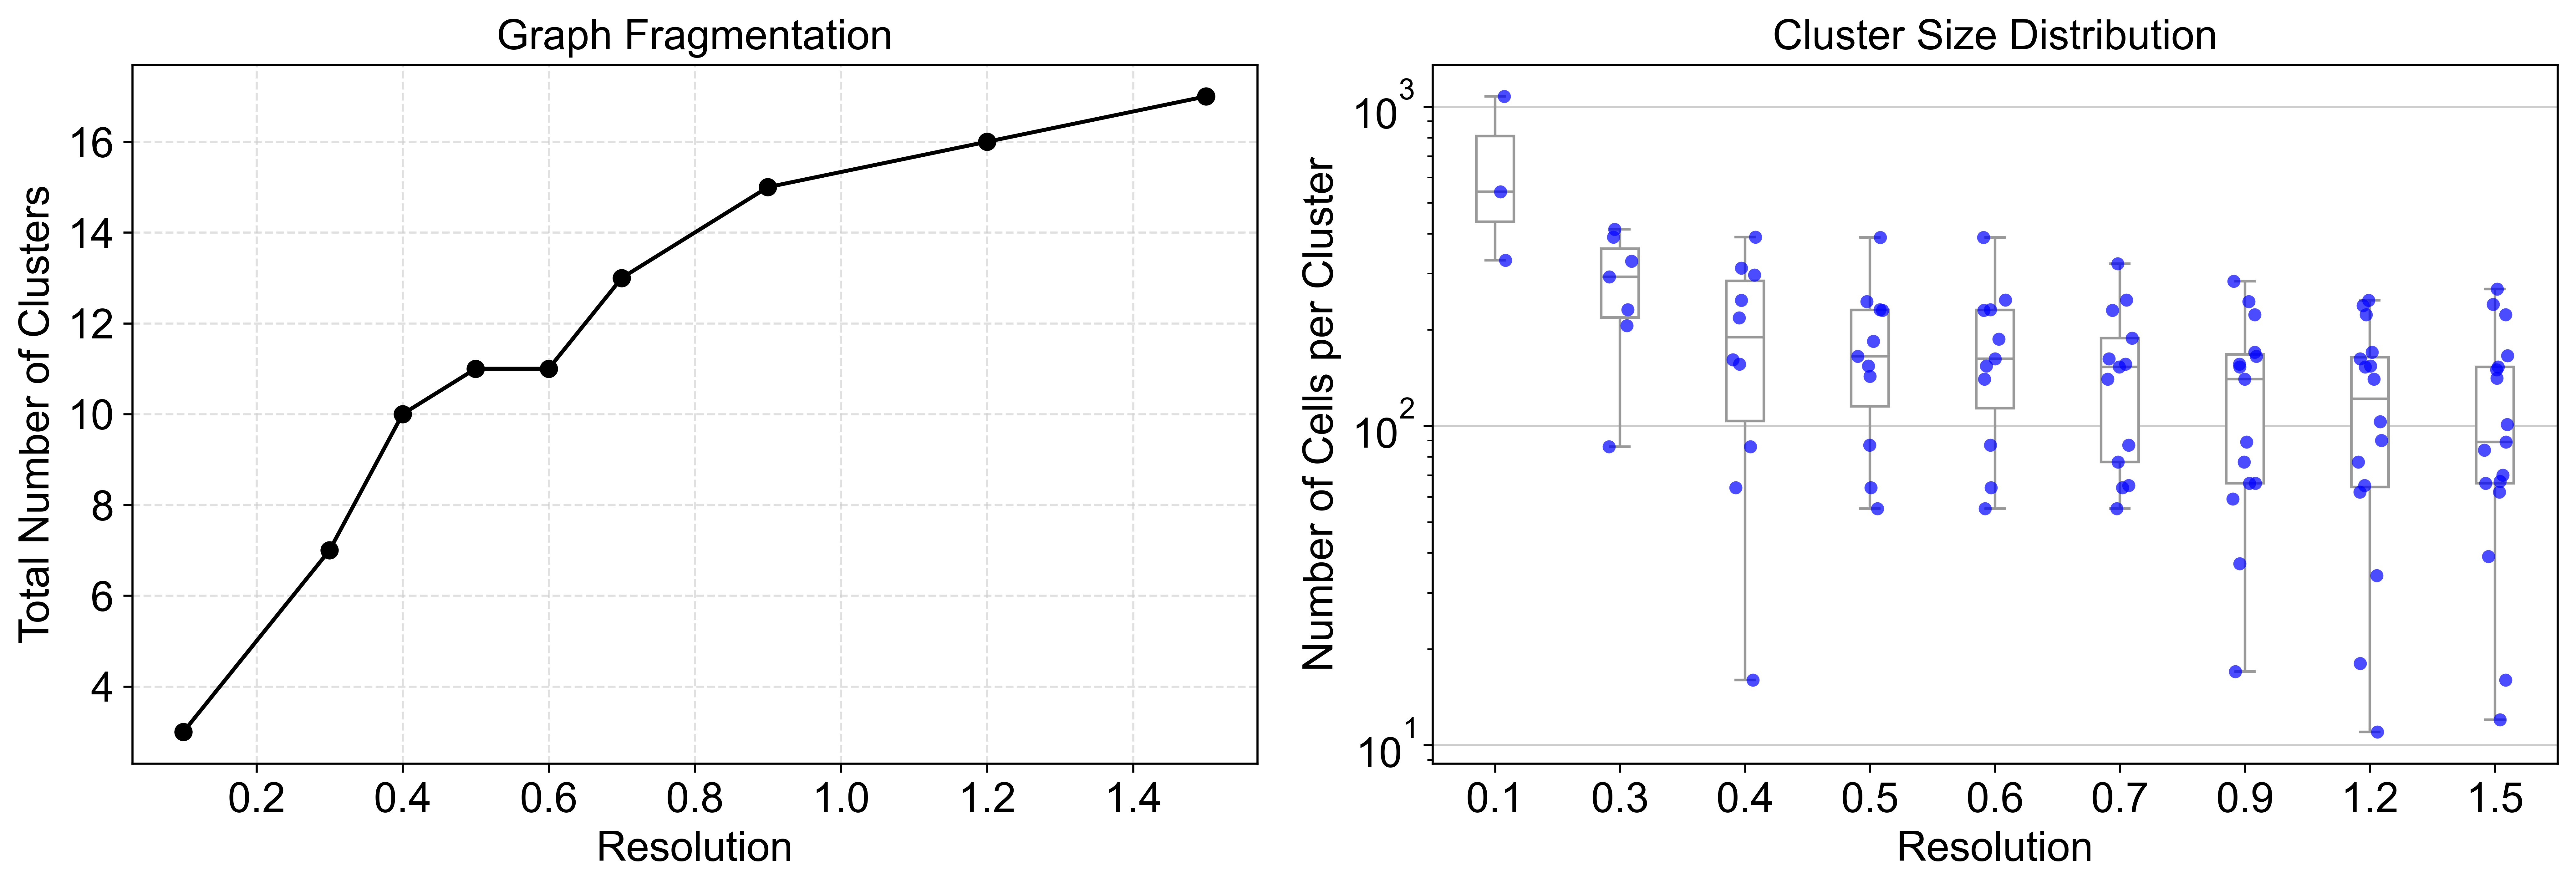

In [3]:
## KNN configuration
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=13, random_state=12)
# -----------------------------------------

resolutions_to_test =[0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1.2, 1.5]
cluster_data =[]

for res in resolutions_to_test:
    # temporarily add leiden clusters to adata.obs
    temp_col = 'leiden_temp'
    sc.tl.leiden(adata, resolution=res, key_added=temp_col)
    
    # exctract info. about clusters
    counts = adata.obs[temp_col].value_counts()
    
    for cluster_id, size in counts.items():
        cluster_data.append({
            'Resolution': res,
            'Cluster_ID': cluster_id,
            'Cell_Count': size
        })
        
    # delete temporal column
    del adata.obs[temp_col]

df_clusters = pd.DataFrame(cluster_data)
print(f"Sweep finished. 'adata' remains untouched. Total records: {len(df_clusters)}")

# PLOT RESULTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Number of clusters vs Resolution
# Group by resolution and count unique clusters
num_clusters = df_clusters.groupby('Resolution')['Cluster_ID'].nunique()
ax1.plot(num_clusters.index, num_clusters.values, marker='o', linestyle='-', color='black')
ax1.set_xlabel('Resolution')
ax1.set_ylabel('Total Number of Clusters')
ax1.set_title('Graph Fragmentation')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: Distribution of Cluster Sizes vs Resolution
# Strip plot to see individual cluster sizes
sns.stripplot(
    data=df_clusters, 
    x='Resolution', 
    y='Cell_Count', 
    jitter=True, 
    alpha=0.7, 
    color='blue',
    ax=ax2
)
# Overlay boxplot to see the median and interquartile range
sns.boxplot(
    data=df_clusters, 
    x='Resolution', 
    y='Cell_Count', 
    color='white', 
    width=0.3, 
    fliersize=0,
    ax=ax2
)
ax2.set_xlabel('Resolution')
ax2.set_ylabel('Number of Cells per Cluster')
ax2.set_title('Cluster Size Distribution')
ax2.set_yscale('log') # Log scale because size variation is usually massive

plt.tight_layout()
plt.show()

## Clustering and global markers

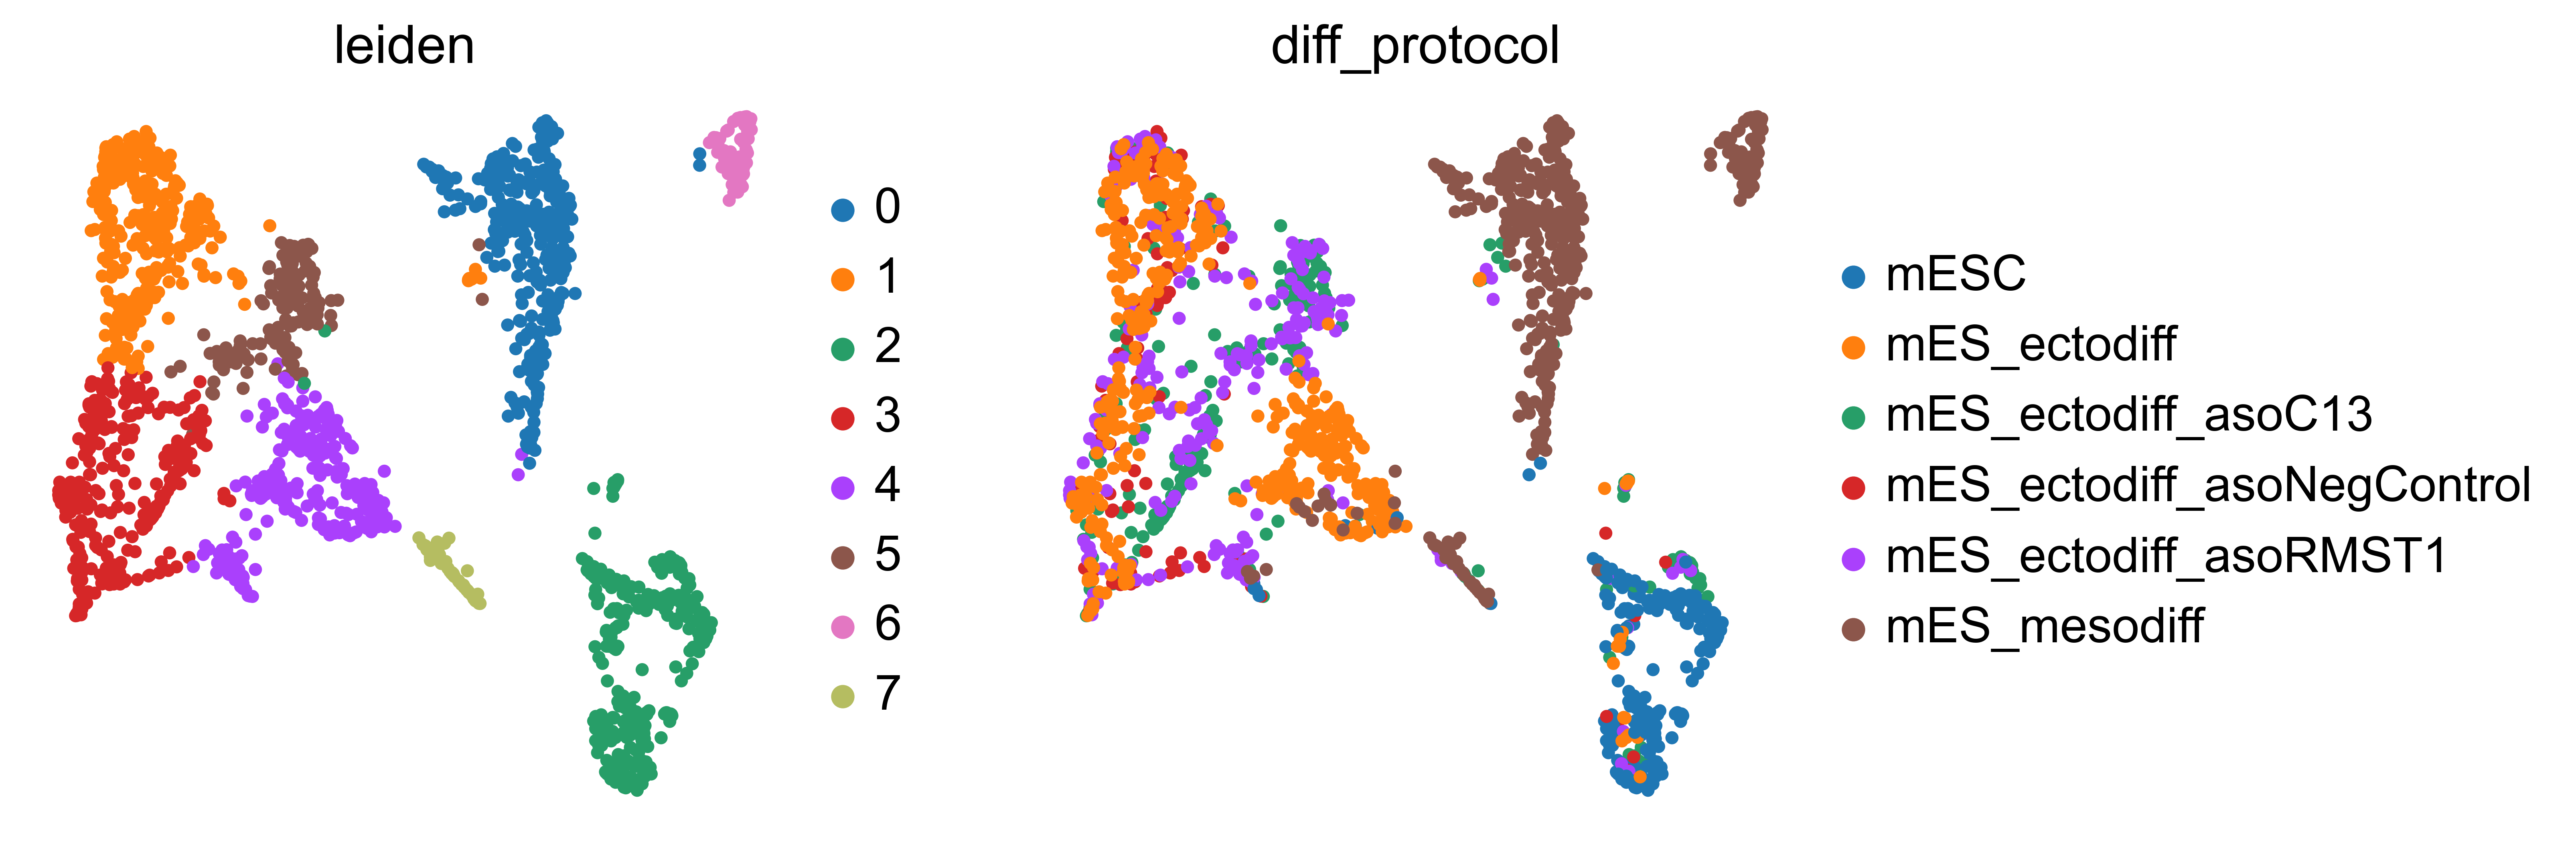

In [4]:
sc.tl.umap(adata, random_state=12, min_dist=0.1, spread=0.75) 

# --- CLUSTERING (Leiden method) ---

# Higher resolution = higher number of clusters

sc.tl.leiden(adata, resolution=0.3, random_state=12)
sc.tl.dendrogram(adata, groupby='leiden')

# Visualize clusters alongside the experiments
sc.pl.umap(adata, color=['leiden','diff_protocol'])

Check the cluster consistency with canonical markers:

Generating targeted Dotplot...


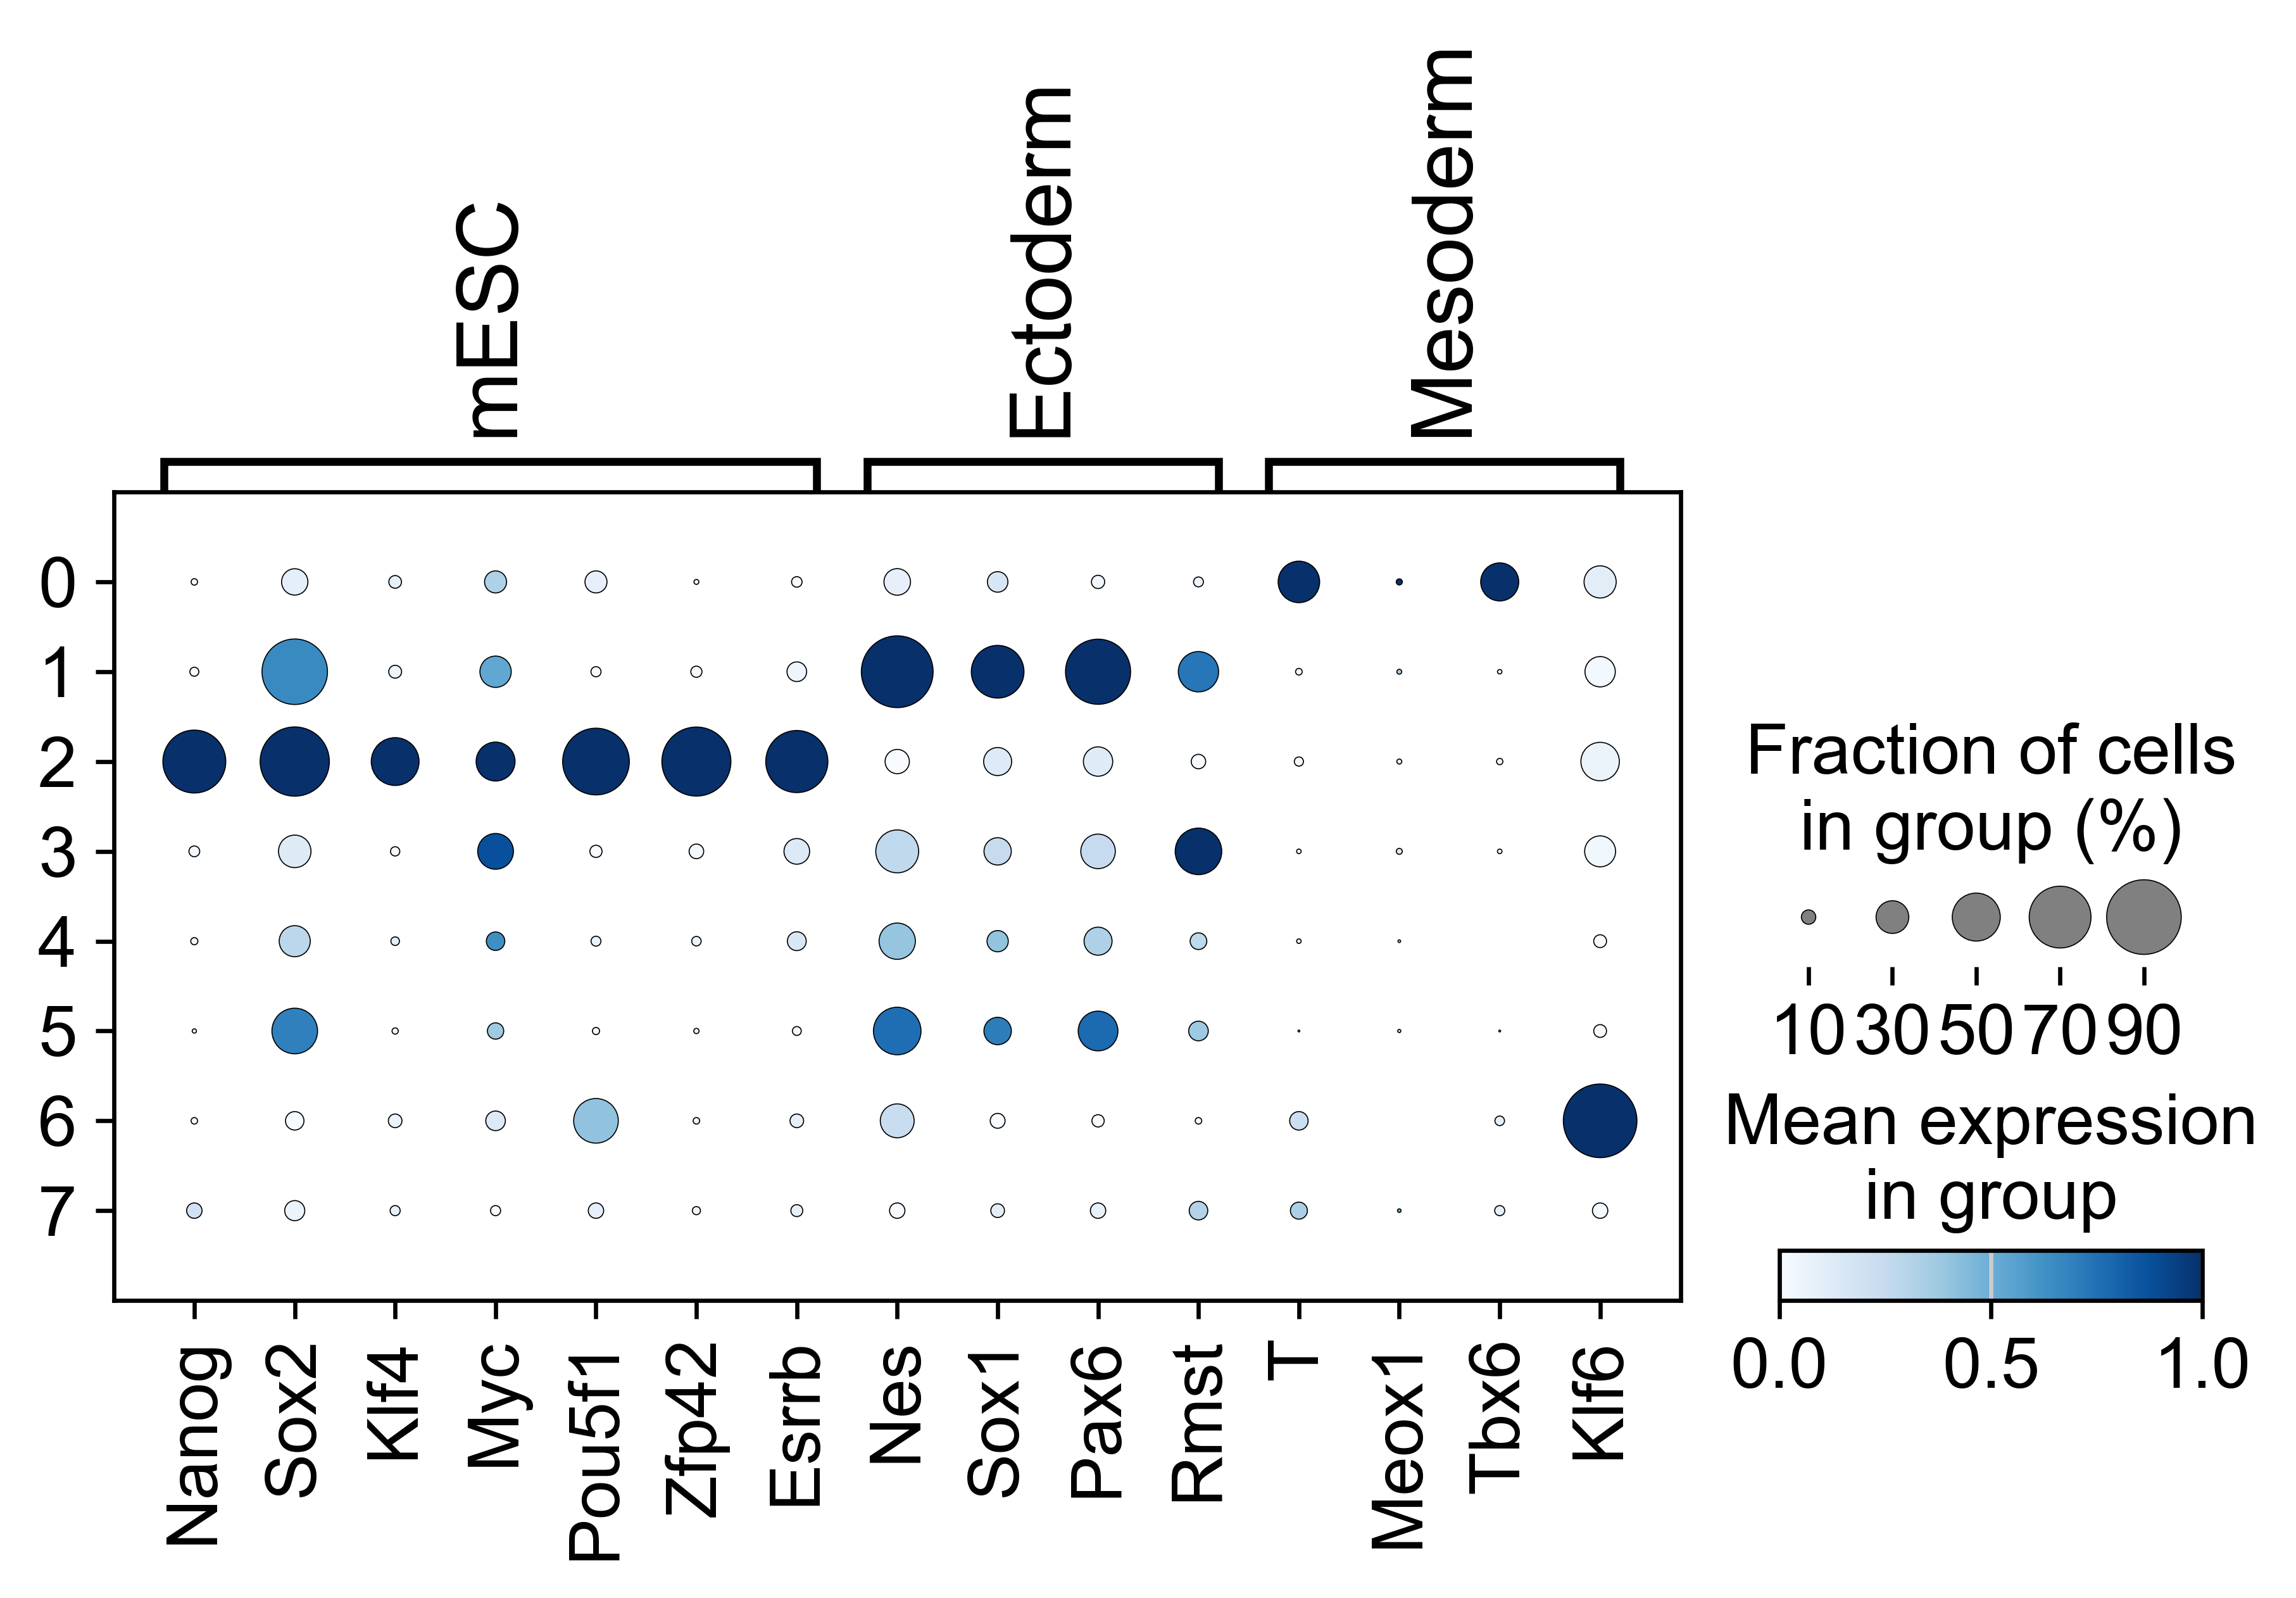

In [5]:
# --- TARGETED MARKER VISUALIZATION ---
# Define your canonical markers of interest
# Add any other literature markers you need
canonical_markers = {
    'mESC':['Nanog','Sox2', 'Klf4','Myc','Pou5f1','Zfp42','Esrrb'],
    'Ectoderm':['Nes','Sox1','Pax6', 'Rmst'],
    'Mesoderm': ['T','Meox1','Tbx6','Klf6']
}

# 1. Dotplot: Standard visualization in scRNA-seq papers.
# Shows both the fraction of cells expressing the gene (dot size) 
# and the mean expression level (color intensity).
print("Generating targeted Dotplot...")
sc.pl.dotplot(
    adata, 
    var_names=canonical_markers, 
    groupby='leiden', 
    standard_scale='var', # Scales data from 0 to 1 per gene for visual comparison
    cmap='Blues'
)

We add some markers to check the anormal clusters: 

1. early ectoderm markers
2. early mesoderm markers
3. endoderm markers

Generating targeted Dotplot...


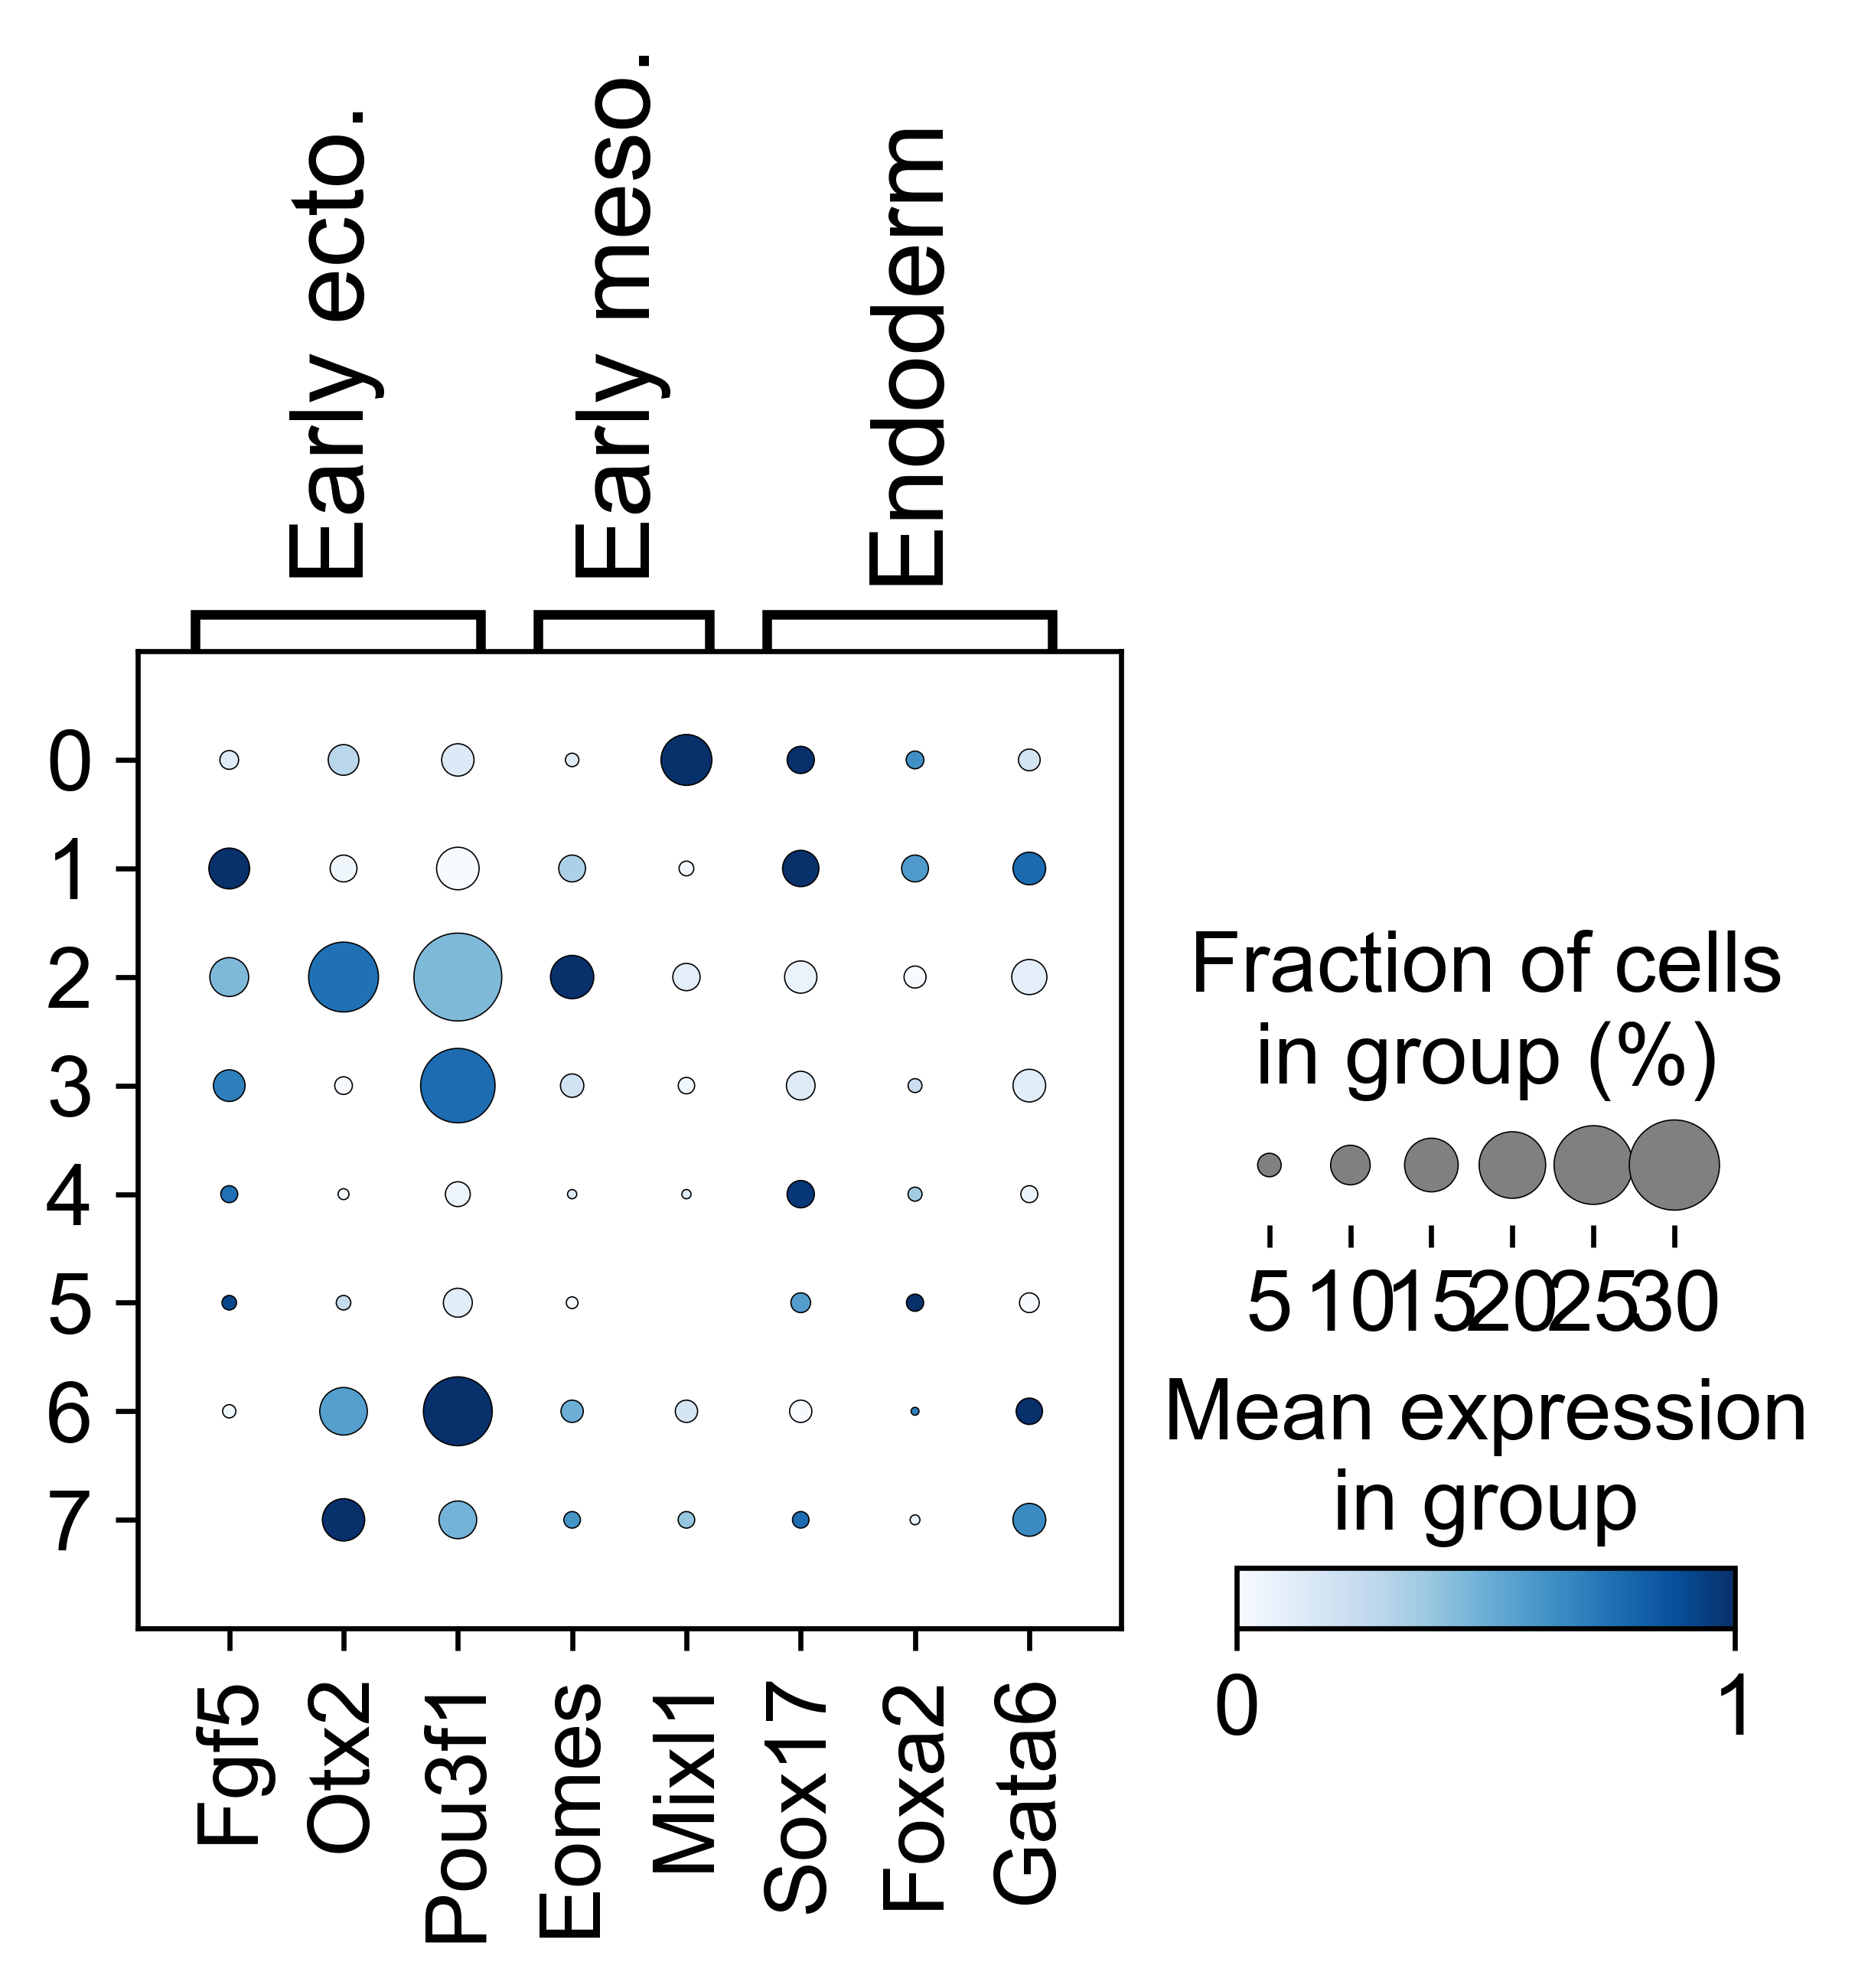

In [6]:
# --- TARGETED MARKER VISUALIZATION ---
# Define your canonical markers of interest
# Add any other literature markers you need
canonical_markers = {
    'Early ecto.':['Fgf5','Otx2','Pou3f1'],
    'Early meso.':['Eomes','Mixl1'],
    'Endoderm': ['Sox17', 'Foxa2','Gata6']
}

# 1. Dotplot: Standard visualization in scRNA-seq papers.
# Shows both the fraction of cells expressing the gene (dot size) 
# and the mean expression level (color intensity).
print("Generating targeted Dotplot...")
sc.pl.dotplot(
    adata, 
    var_names=canonical_markers, 
    groupby='leiden', 
    standard_scale='var', # Scales data from 0 to 1 per gene for visual comparison
    cmap='Blues'
)

Top genes per cluster:

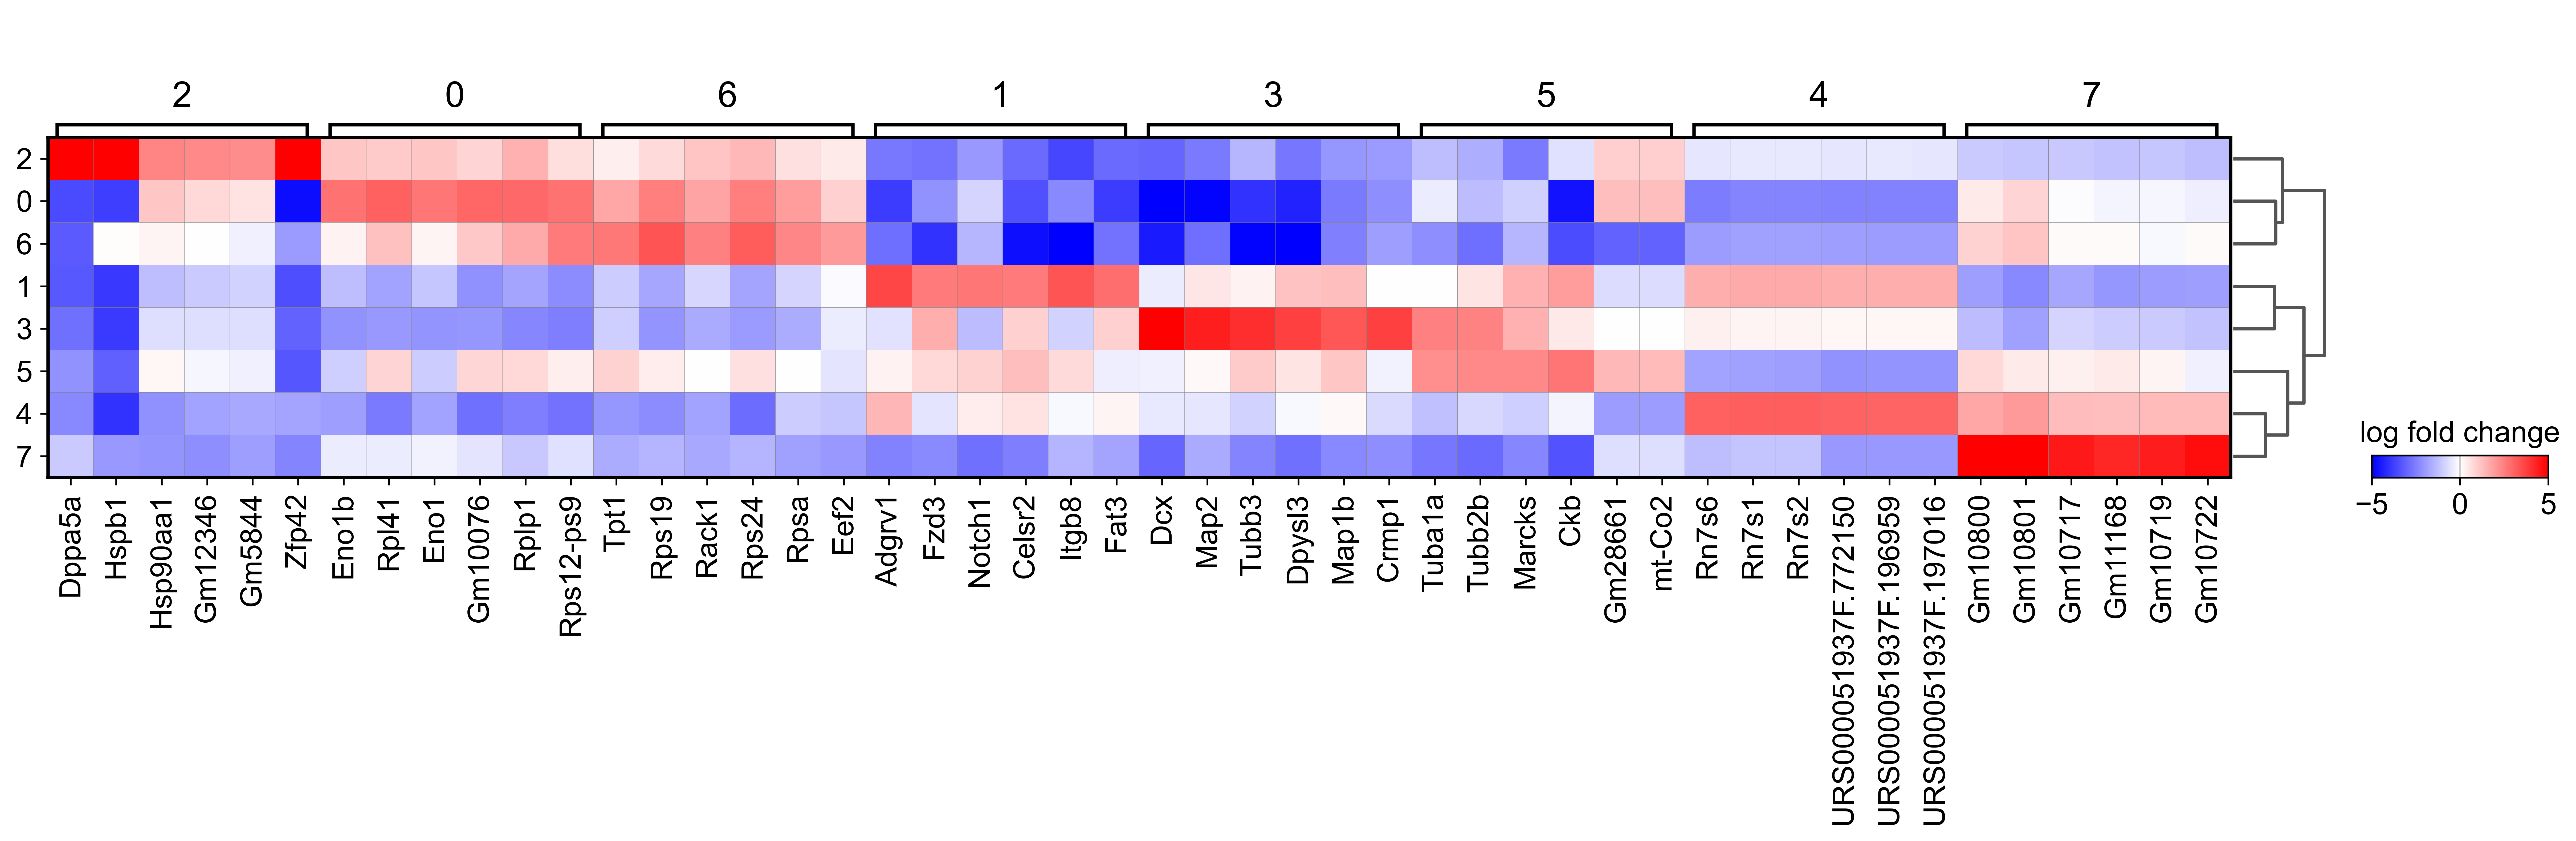

In [7]:
# --- IDENTIFY MARKER GENES PER CLUSTER ---
# We use Wilcoxon rank-sum test. 
# Scanpy automatically uses adata.raw (LogNorm data without z score!!)
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', key_added='DE_leiden')

# Plot top genes per cluster  
sc.pl.rank_genes_groups_matrixplot(
    adata, 
    n_genes=6, 
    values_to_plot='logfoldchanges', 
    cmap='bwr', 
    vmin=-5, vmax=5, 
    min_logfoldchange=1.0, # Only show genes with a strong fold change
    key='DE_leiden'
)

Composition clusters VS experiments:

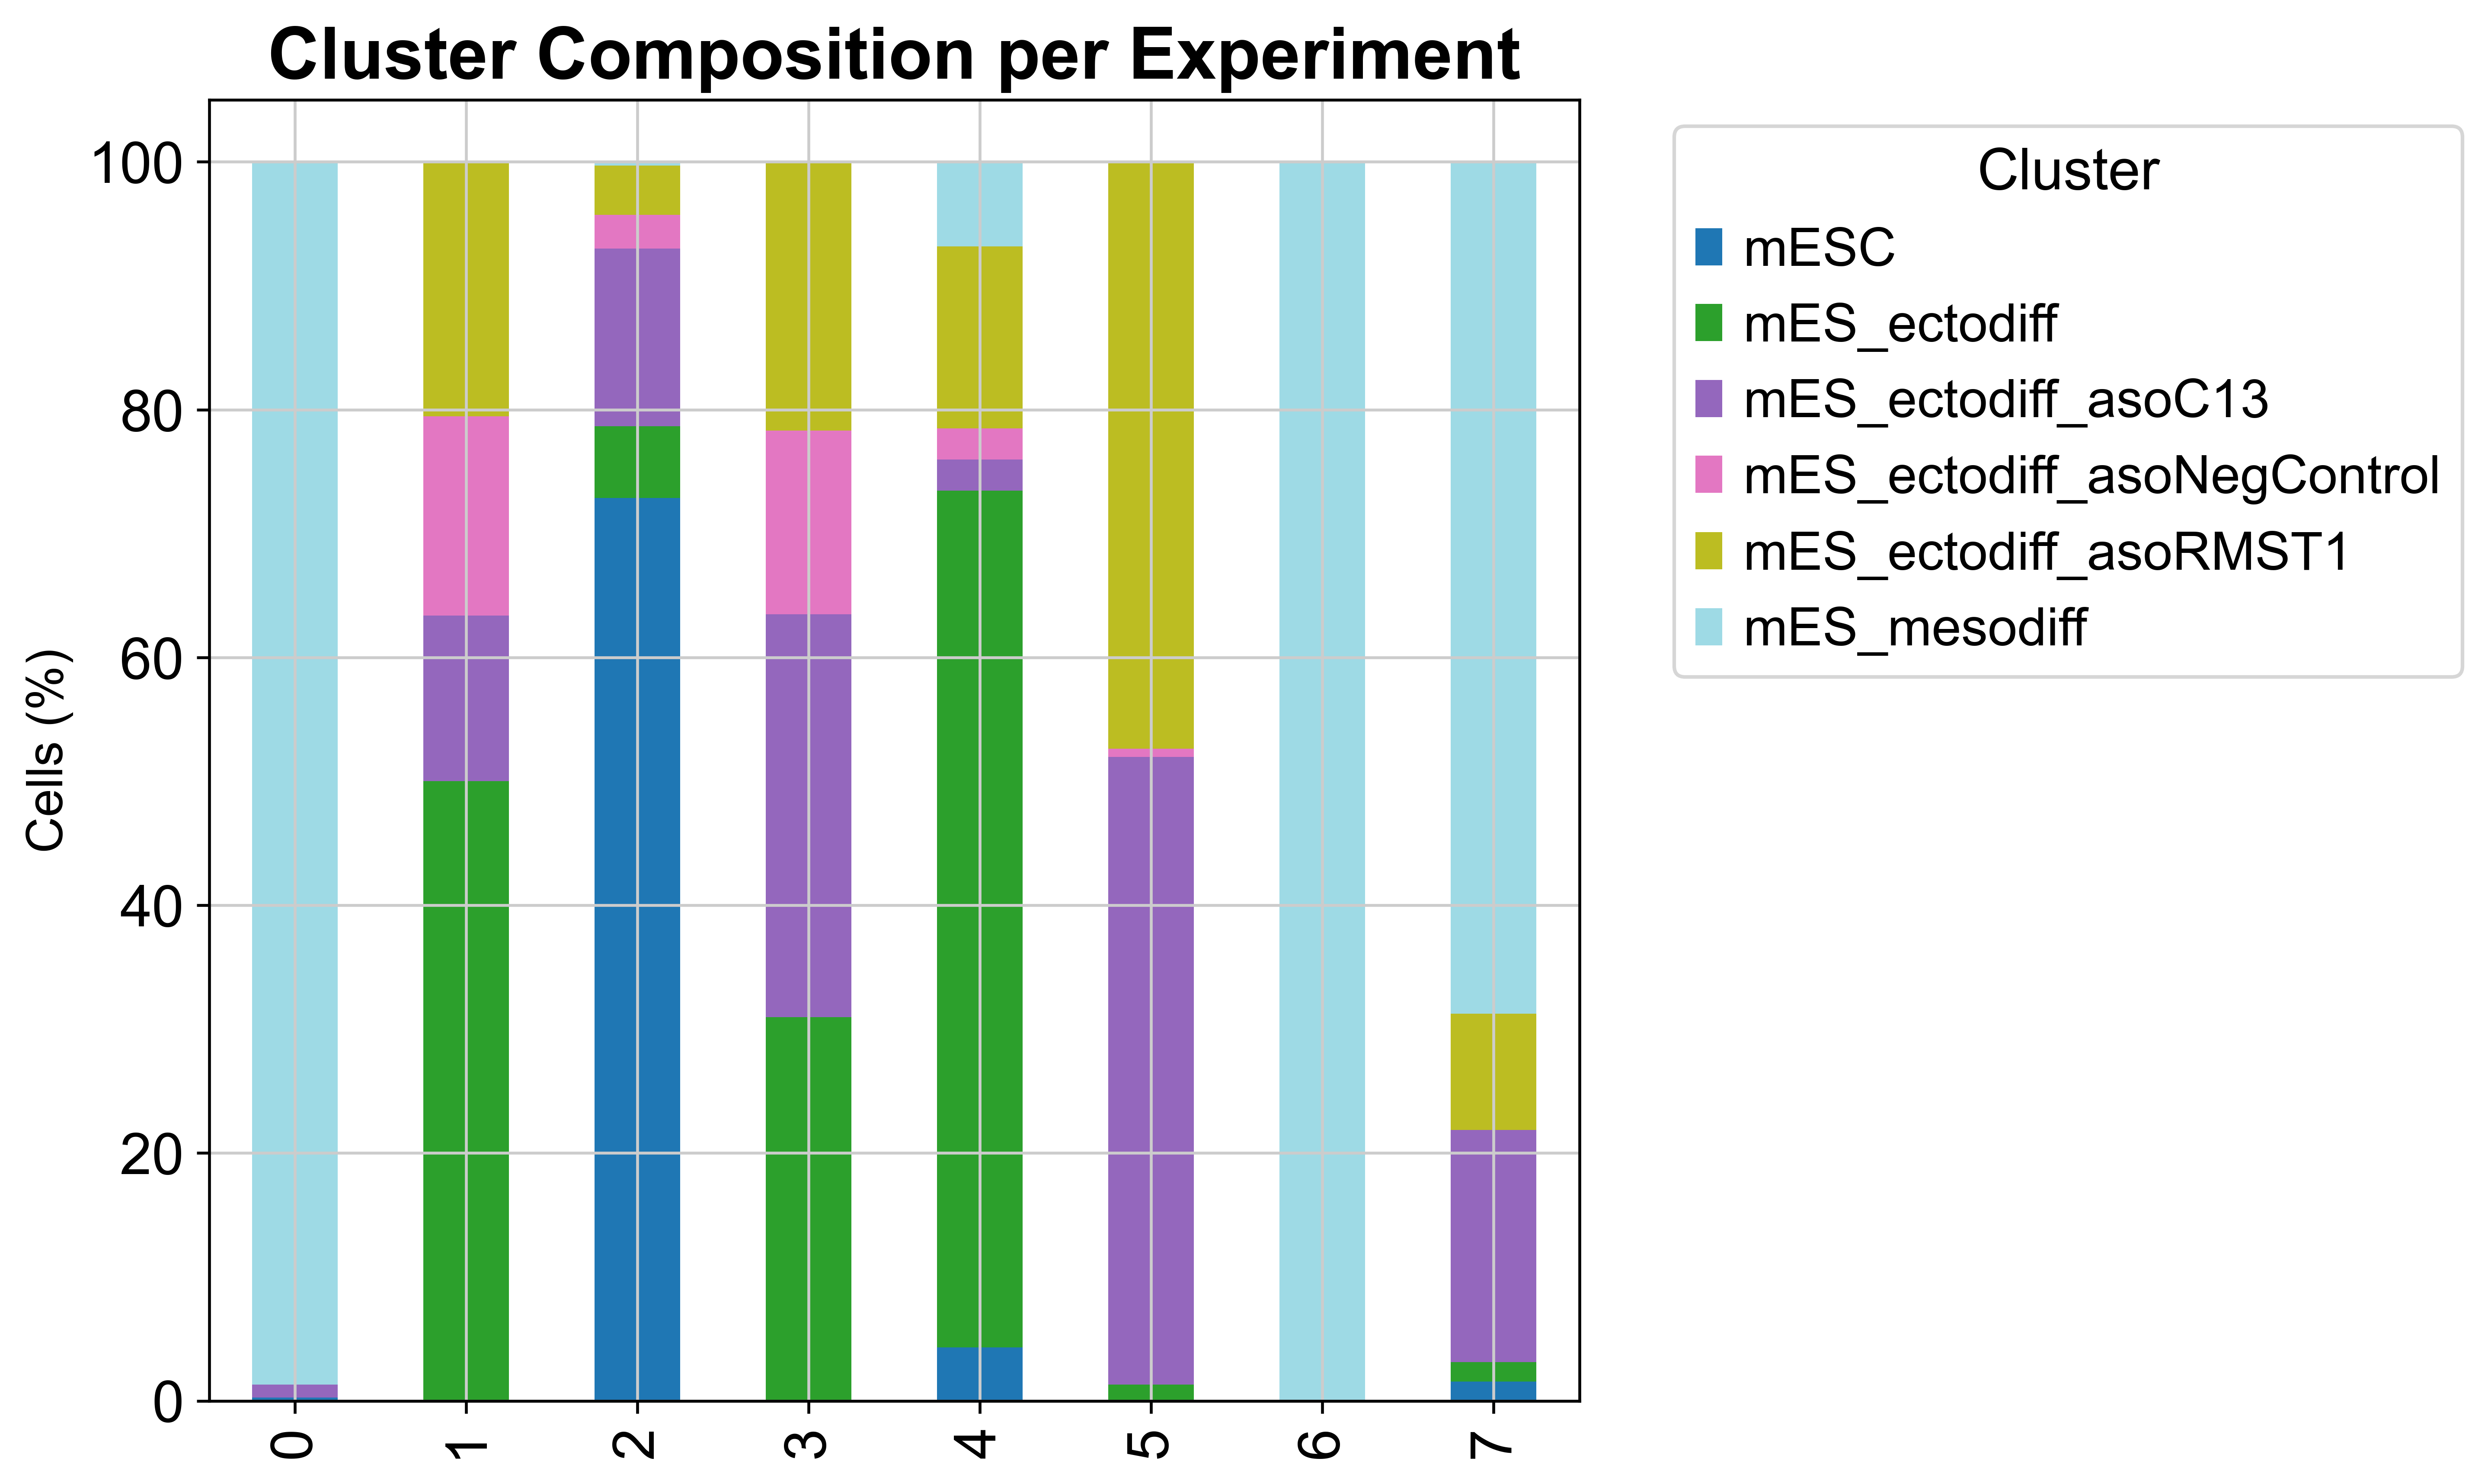

In [8]:
# Create a crosstab counting how many cells from each experiment are in each cluster
composition = pd.crosstab(adata.obs['leiden'], adata.obs['diff_protocol'], normalize='index') * 100

# Plotting as a stacked bar chart
ax = composition.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("Cluster Composition per Experiment", fontsize=20, fontweight='bold')
plt.ylabel("Cells (%)", fontsize=14)
plt.xlabel("")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
## Check the cells per cluster
adata.obs['leiden'].value_counts().sort_values(ascending=False)

leiden
0    379
1    336
2    328
3    323
4    279
5    152
6     86
7     64
Name: count, dtype: int64

In [10]:
## Check the distribution of diff_protocol across clusters
pd.crosstab(adata.obs['leiden'], adata.obs['diff_protocol'], normalize='index')

diff_protocol,mESC,mES_ectodiff,mES_ectodiff_asoC13,mES_ectodiff_asoNegControl,mES_ectodiff_asoRMST1,mES_mesodiff
leiden,,,,,,
0,0.002639,0.000000,0.010554,0.000000,0.000000,0.986807
1,0.000000,0.500000,0.133929,0.160714,0.205357,0.000000
2,0.728659,0.057927,0.143293,0.027439,0.039634,0.003049
3,0.000000,0.309598,0.325077,0.148607,0.216718,0.000000
4,0.043011,0.691756,0.025090,0.025090,0.146953,0.068100
5,0.000000,0.013158,0.506579,0.006579,0.473684,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
7,0.015625,0.015625,0.187500,0.000000,0.093750,0.687500


Analyze what types of non coding RNA is enriched in ectoderm clusters


 BIOTYPE DIAGNOSIS FOR CLUSTER 5
--- Biotype Composition of Top 100 Genes ---
gene_biotype
protein_coding            84
processed_pseudogene       7
unprocessed_pseudogene     6
piRNA                      2
lincRNA                    1

--- Top 15 Genes Driving Cluster 5 ---
  names  logfoldchanges    pvals_adj   gene_biotype
 Pantr1        2.803301 2.503300e-09        lincRNA
   Rbp1        2.731603 3.054267e-22 protein_coding
    Ckb        2.723174 5.179084e-32 protein_coding
  Fabp7        2.655555 4.344590e-10 protein_coding
 Marcks        2.341449 1.946241e-40 protein_coding
 Tubb2b        2.318025 4.629652e-41 protein_coding
  Glra1        2.302736 1.195282e-02 protein_coding
   Pdpn        2.244509 6.269166e-04 protein_coding
   Nnat        2.229141 4.963710e-18 protein_coding
 Tuba1a        2.187974 6.091703e-42 protein_coding
   Hes6        2.167139 8.030258e-03 protein_coding
  Nr2f1        2.124230 1.677387e-11 protein_coding
   Irx3        2.045014 2.264617e-05 protein_co

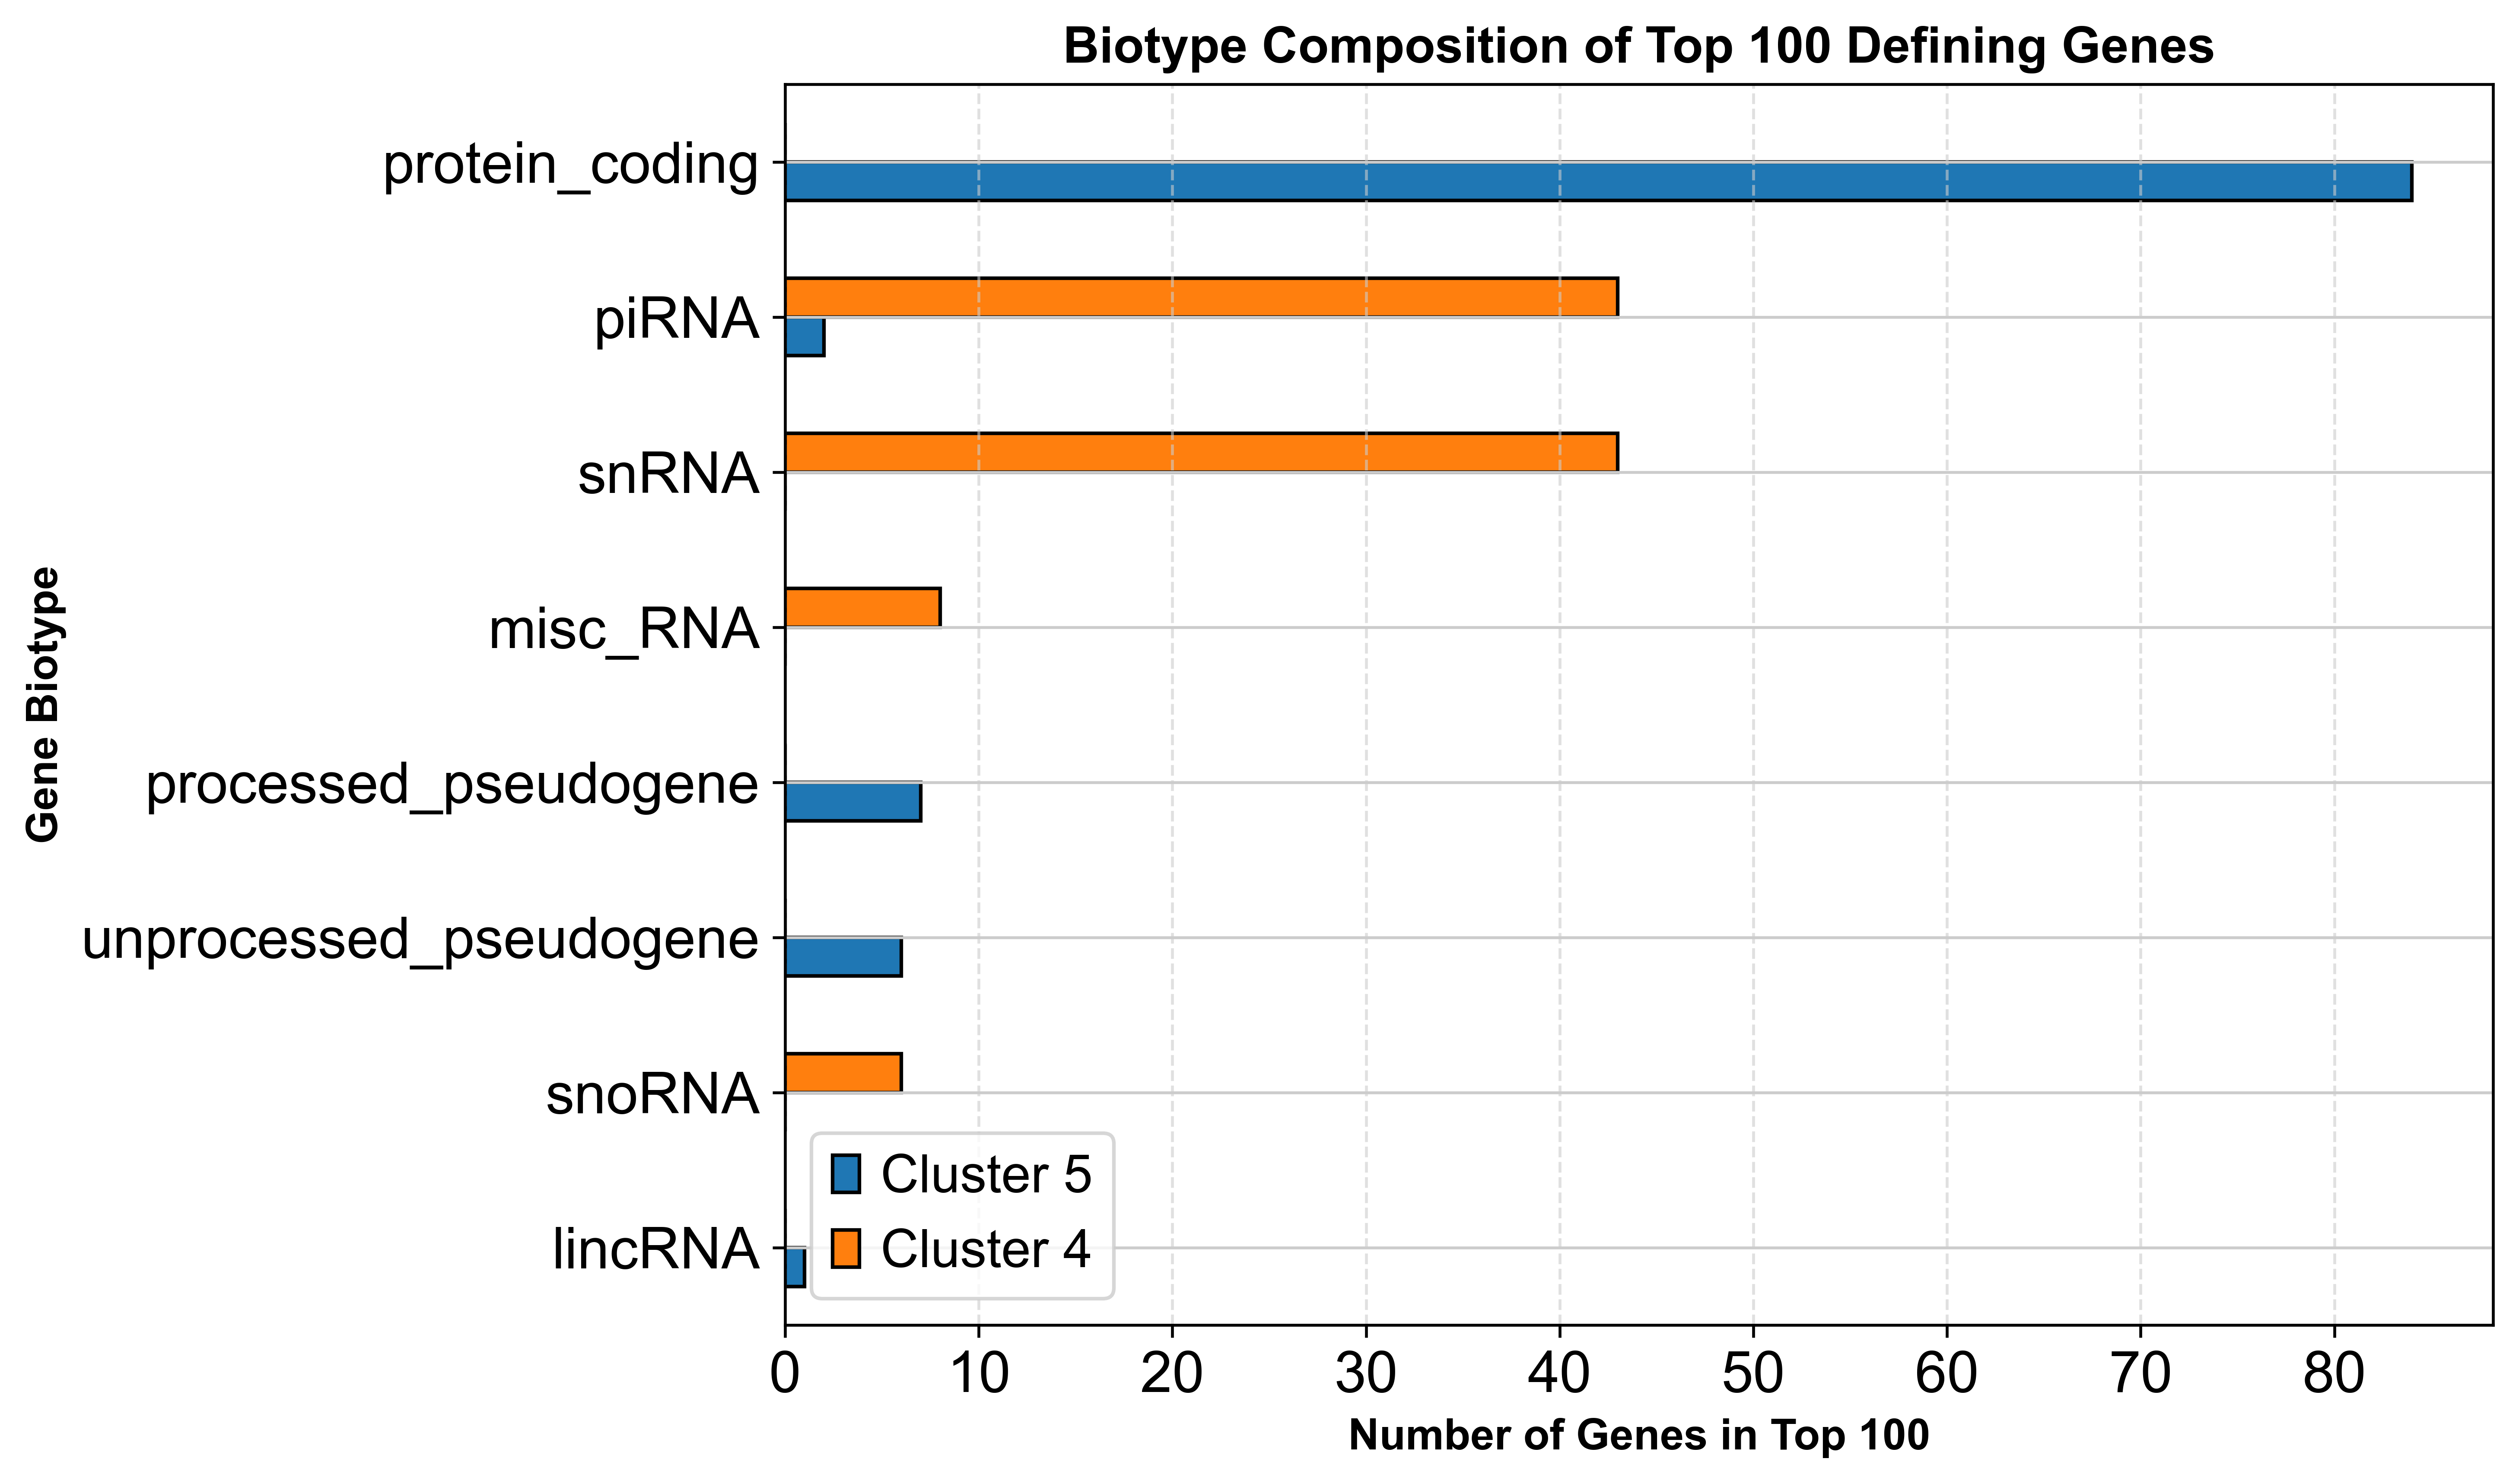

In [11]:
def analyze_cluster_biotypes(adata, cluster_id, top_n=100):
    """
    Extracts the top differentially expressed genes for a given cluster
    and maps them to their biological biotypes to detect technical artifacts.
    """
    print(f"\n==========================================")
    print(f" BIOTYPE DIAGNOSIS FOR CLUSTER {cluster_id}")
    print(f"==========================================")
    
    # 1. Extract raw leiden DE results
    df = sc.get.rank_genes_groups_df(adata, group=str(cluster_id), key='DE_leiden')
    
    # 2. Filter for statistical significance to avoid noise
    mask_sig = df['pvals_adj'] < 0.05
    df_sig = df[mask_sig].copy()
    
    if len(df_sig) == 0:
        print(f"WARNING: No significant genes found for cluster {cluster_id}.")
        return None
        
    # 3. Get the top N most overexpressed genes driving this cluster
    df_sig = df_sig.sort_values('logfoldchanges', ascending=False).head(top_n)
    
    # 4. Extract Biotype Mapping from metadata (FIXED: Cast to string to break Categorical limits)
    if adata.raw is not None and 'gene_biotype' in adata.raw.var.columns:
        biotype_map = adata.raw.var['gene_biotype'].astype(str)
    elif 'gene_biotype' in adata.var.columns:
        biotype_map = adata.var['gene_biotype'].astype(str)
    else:
        print("ERROR: 'gene_biotype' not found in adata metadata.")
        return None
        
    # 5. Map the biotypes to our significant genes (Now fillna will work perfectly)
    df_sig['gene_biotype'] = df_sig['names'].map(biotype_map).fillna('unknown')
    
    # 6. Print Results
    biotype_counts = df_sig['gene_biotype'].value_counts()
    
    print(f"--- Biotype Composition of Top {len(df_sig)} Genes ---")
    print(biotype_counts.to_string())
    
    print(f"\n--- Top 15 Genes Driving Cluster {cluster_id} ---")
    print(df_sig[['names', 'logfoldchanges', 'pvals_adj', 'gene_biotype']].head(15).to_string(index=False))
    
    return biotype_counts

# --- 1. RUN DIAGNOSIS ON SUSPECT CLUSTERS ---
# We analyze cluster 2 and 4 (change numbers if needed)
counts_5 = analyze_cluster_biotypes(adata, cluster_id='5', top_n=100)
counts_4 = analyze_cluster_biotypes(adata, cluster_id='4', top_n=100)

# --- 2. VISUALIZATION (COMPARATIVE BAR CHART) ---
if counts_5 is not None and counts_4 is not None:
    print("\n--- GENERATING COMPARATIVE PLOT ---")
    
    # Combine counts into a single DataFrame for plotting
    df_plot = pd.DataFrame({
        'Cluster 5': counts_5, 
        'Cluster 4': counts_4
    }).fillna(0) # Fill NaN with 0 for biotypes that only appear in one cluster
    
    # Sort by the most abundant biotypes globally for a cleaner plot
    df_plot['Total'] = df_plot['Cluster 5'] + df_plot['Cluster 4']
    df_plot = df_plot.sort_values('Total', ascending=True).drop('Total', axis=1)
    
    # Plotting Horizontal Bar Chart
    ax = df_plot.plot(
        kind='barh', 
        stacked=False, 
        figsize=(10, 6), 
        color=['#1f77b4', '#ff7f0e'],
        edgecolor='black'
    )
    
    plt.title("Biotype Composition of Top 100 Defining Genes", fontsize=14, fontweight='bold')
    plt.xlabel("Number of Genes in Top 100", fontsize=12, fontweight='bold')
    plt.ylabel("Gene Biotype", fontsize=12, fontweight='bold')
    
    # Add vertical grid for readability
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

We observe the perturbed cluster aso (ID 5) is not dominated by ncRNA, while the 'failed' ectoderm cluster (ID 4) it is absolutely dominated by it.

## Check matrixplot with protein coding constraint

=> example of filtering by protein coding + logfold + pvalue

In [12]:
## Check structure in DataFrame format
df = sc.get.rank_genes_groups_df(adata, group='0', key='DE_leiden')
df

,names,scores,logfoldchanges,pvals,pvals_adj
0,Eno1b,25.944208,2.758582,2.113586e-148,5.159369e-143
1,Rpl41,25.877827,3.109013,1.183390e-147,1.444358e-142
2,Eno1,25.732235,2.684356,5.095956e-146,4.146495e-141
3,Gm10076,25.080936,2.985268,8.029898e-139,4.900345e-134
4,Rplp1,24.316523,2.947144,1.310980e-130,6.400334e-126
...,...,...,...,...,...
244100,URS0000019C38.36190,-20.313692,-3.326018,9.730786e-92,1.193635e-88
244101,URS0000019C38.155630,-20.320412,-3.324750,8.486204e-92,1.051535e-88
244102,URS0000019C38.36183,-20.353704,-3.332838,4.304812e-92,5.473053e-89
244103,URS0000019C38.155647,-20.369892,-3.334951,3.093551e-92,3.995510e-89


In [13]:
## check that pvals are in the expected range (0 to 1)
np.array(df['pvals']).max()

np.float64(1.0)

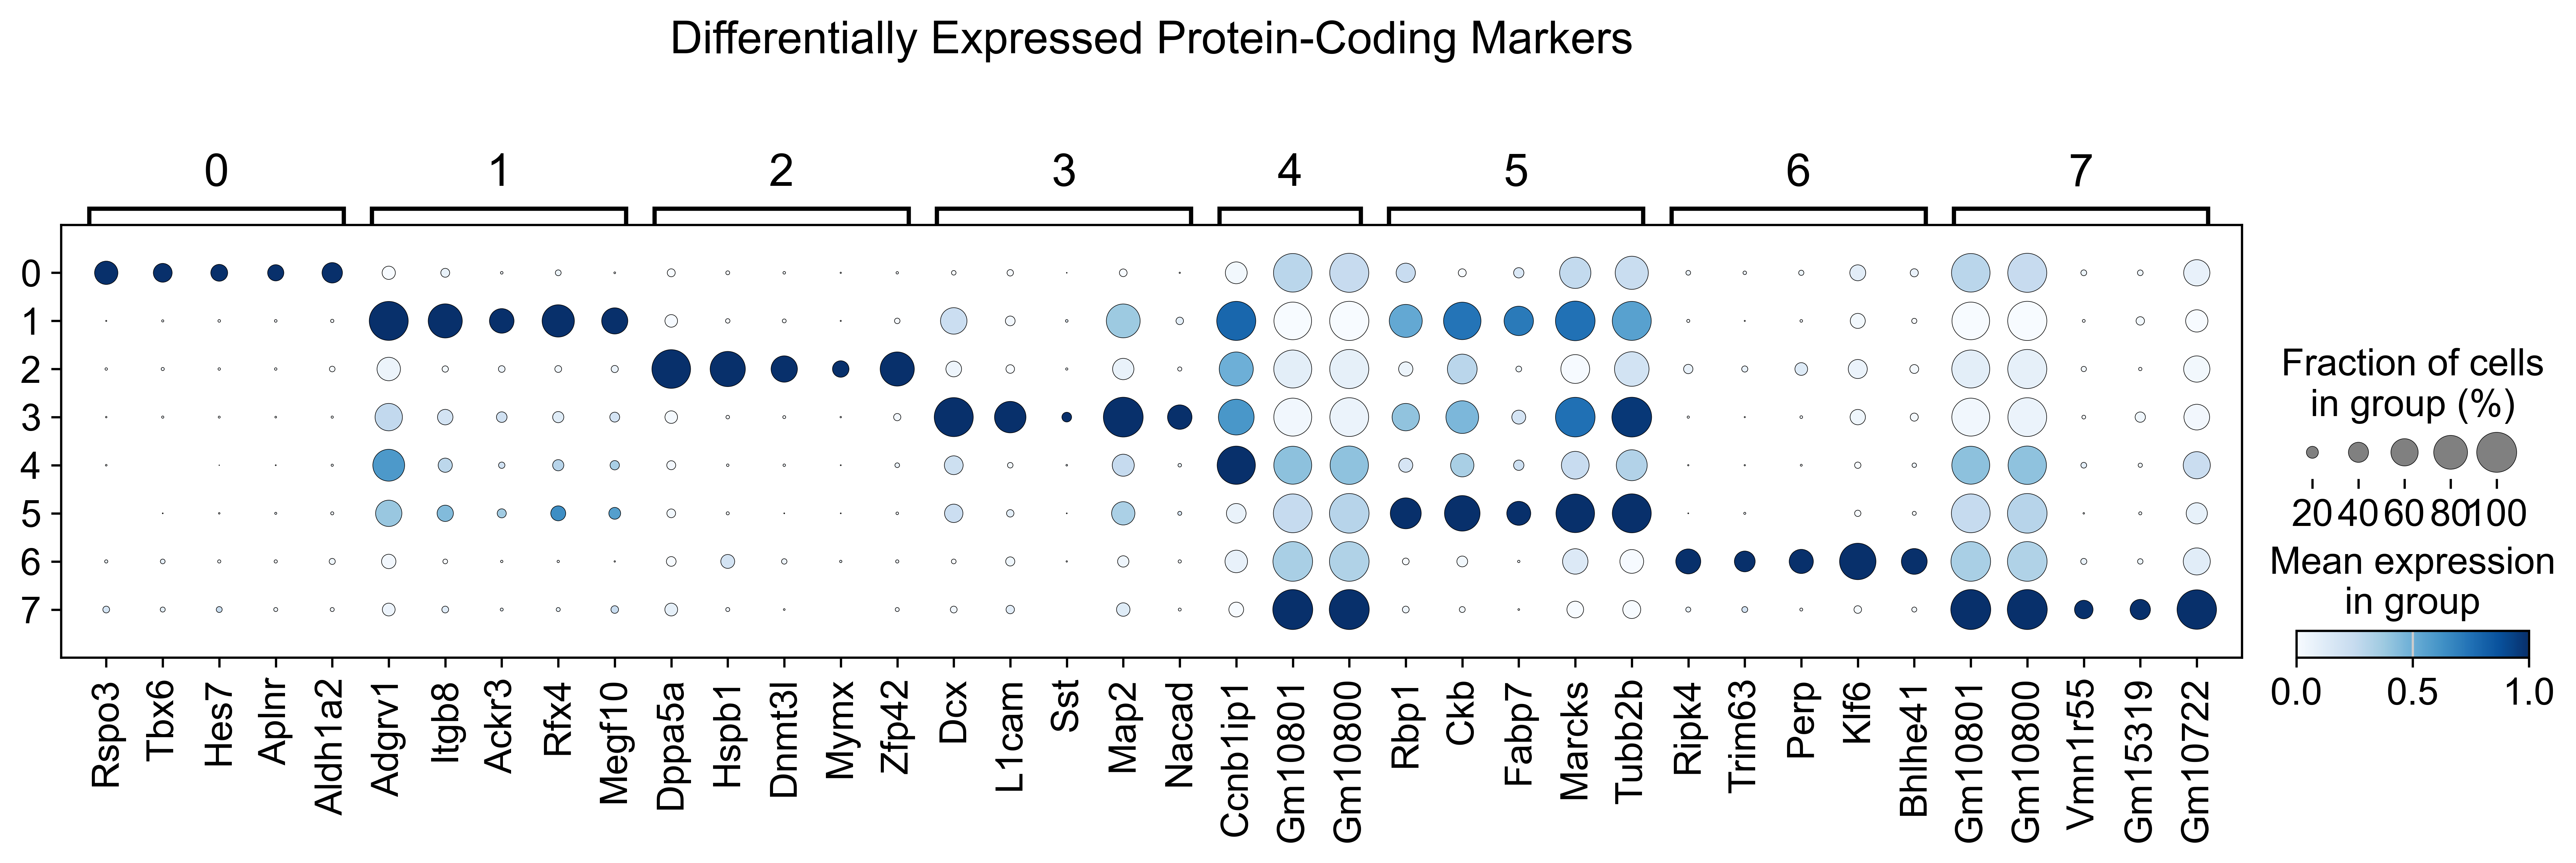

In [14]:
# Dictionary to store the selectioned genes for each cluster
clean_marker_dict = {}

# Ensure we have the biotype mapping
biotype_map = adata.raw.var['is_protein_coding'].fillna(False)

# Get all unique clusters
clusters = sorted(adata.obs['leiden'].unique(), key=int)

for cluster_id in clusters:
    # Extract raw DE results for this cluster
    df = sc.get.rank_genes_groups_df(adata, group=str(cluster_id), key='DE_leiden')
    
    # Map the protein_coding boolean
    df['is_protein_coding'] = df['names'].map(biotype_map).fillna(False)
    
    # --- APPLY FILTERS ---
    # 1. Protein coding only
    # 2. Significant (p_adj < 0.01)
    # 3. High Amplitude (LogFC > 1.5)
    # 4. Remove Ribosomic/Mitochondrial genes

    mask_protein = df['is_protein_coding'] == True
    mask_stats = (df['pvals_adj'] < 0.01) & (df['logfoldchanges'] > 1.5)
    mask_noise = ~df['names'].str.startswith(('Rps', 'Rpl', 'mt-', 'MT-'))
    
    # Combine masks and sort
    df_clean = df[mask_protein & mask_stats & mask_noise].sort_values('logfoldchanges', ascending=False)
    
    # Get Top 5 genes for plotting
    top_genes = df_clean.head(5)['names'].tolist()
    
    # Save to dictionary if it found any genes
    if len(top_genes) > 0:
        clean_marker_dict[str(cluster_id)] = top_genes
    else:
        print(f"Cluster {cluster_id}: No genes passed the strict filter.")

# Dotplot
sc.pl.dotplot(
    adata, 
    var_names=clean_marker_dict, 
    groupby='leiden',
    use_raw=True,
    standard_scale='var',
    cmap='Blues',
    title="Differentially Expressed Protein-Coding Markers"
)

We check if the cluster 4 and 7 are in a proliferative state by looking at the cell cycle scores => NO!!!

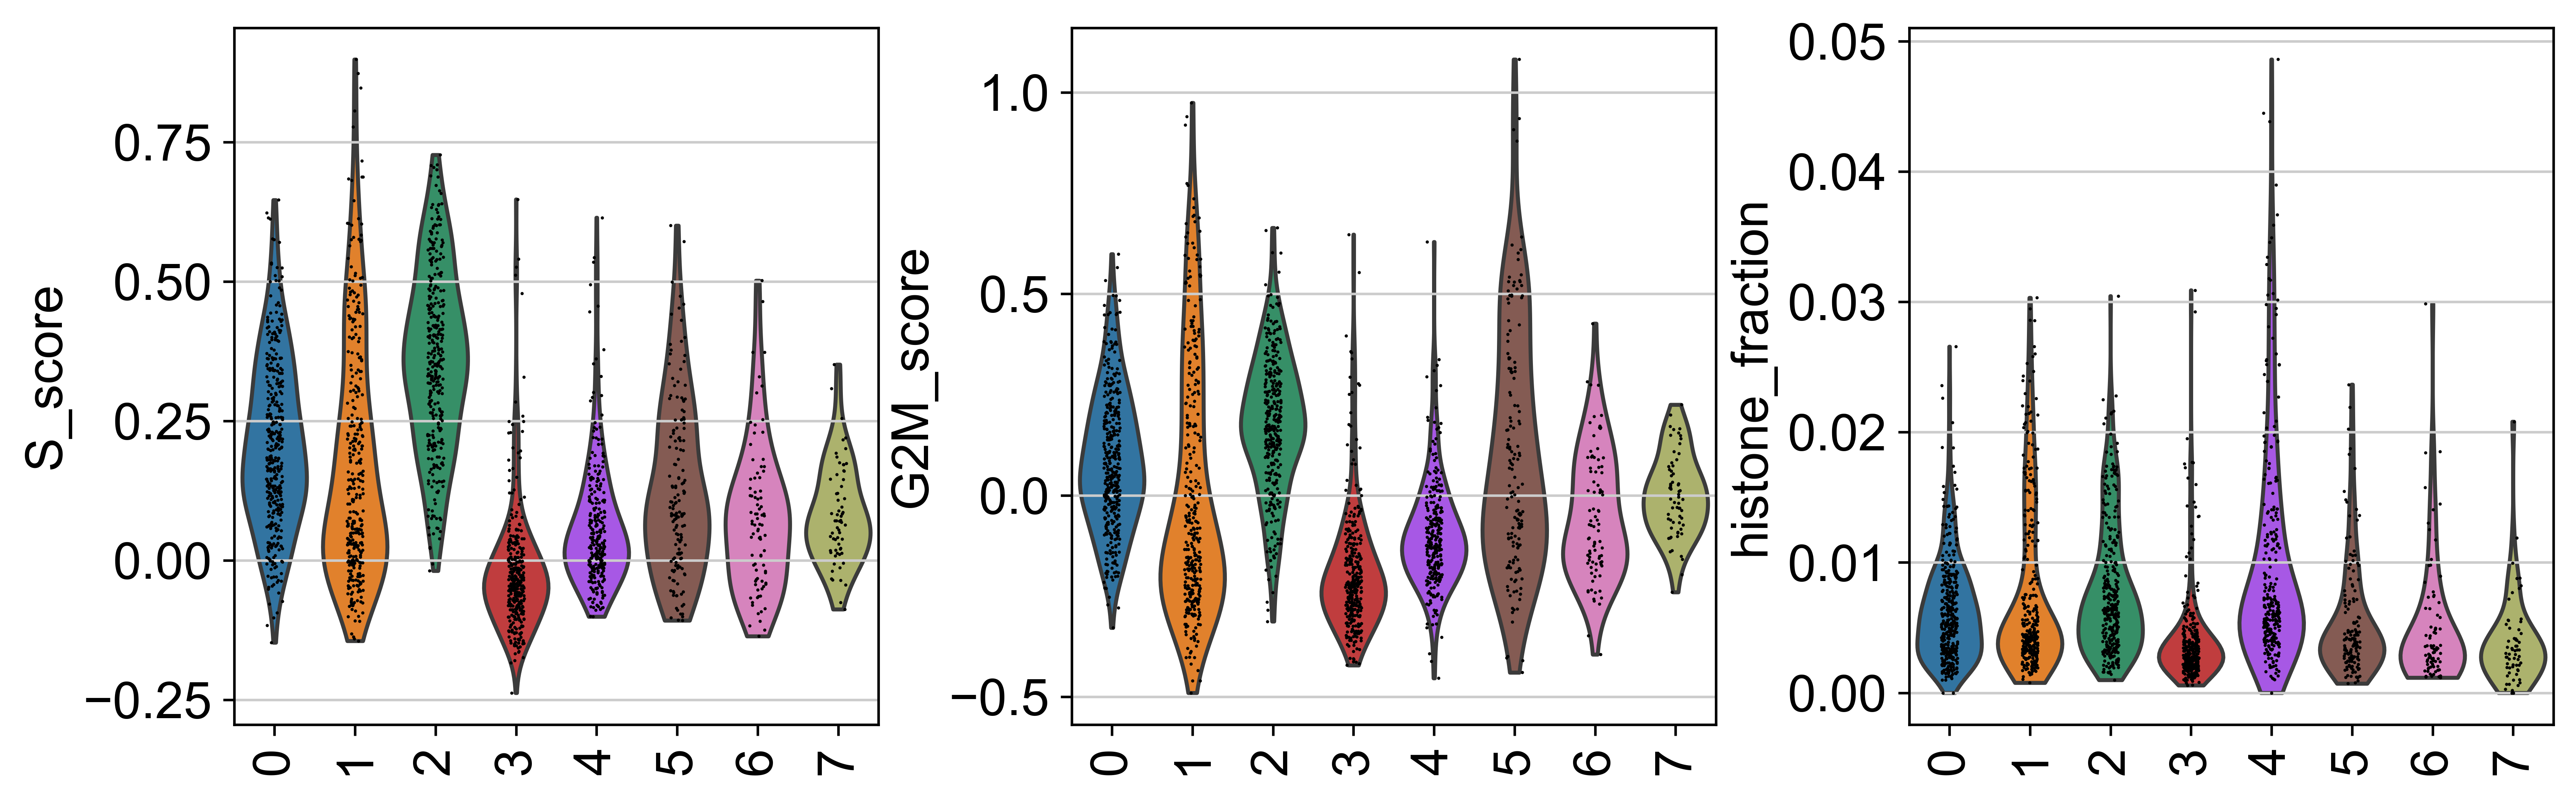

In [15]:
# Define the proliferation metrics we already calculated in .obs
proliferation_metrics = ['S_score', 'G2M_score', 'histone_fraction']

if len(proliferation_metrics) > 0:
    # Violin plot
    sc.pl.violin(
        adata, 
        keys=proliferation_metrics, 
        groupby='leiden', 
        rotation=90, 
        stripplot=True,  # Set to True if you want to see individual cells as points
    )

## GO enrichment (upregulated)

-> Only uses protein coding genes (for bio. process identification)

1. At least LogFoldchange > 1.5

2. At least p_val < 0.01

In [ ]:
# ==========================================
# FUNCTION TO EXTRACT CLEAN GO GENES
# ==========================================
def get_go_genes(adata, cluster_id):
    """
    Extracts protein-coding markers. Tries a strict threshold first. 
    If it fails to find enough genes (transitional state), it lowers the amplitude threshold.
    """
    df = sc.get.rank_genes_groups_df(adata, group=str(cluster_id), key='DE_leiden')
    var_meta = adata.raw.var[['is_protein_coding']].copy()
    df = df.merge(var_meta, left_on='names', right_index=True, how='left')
    
    noise_prefixes = ('Rps', 'Rpl', 'mt-', 'MT-', 'Gm', 'Rik')
    mask_ribo = ~df['names'].str.startswith(noise_prefixes)

    # Minimal p value, protein-coding status and ribosomal/mito noise removal
    mask_noise = (
        (df['is_protein_coding'] == True) & 
        (df['pvals_adj'] < 0.05) & 
        (mask_ribo)
    )

    # Strict criteria
    mask_strict = mask_noise & (df['logfoldchanges'] > 1.5)
    df_clean = df[mask_strict].sort_values(by='logfoldchanges', ascending=False)
    
    if len(df_clean) >= 5:
        print(f"Cluster {cluster_id}: Strict criteria (FC > 1.5). Genes: {len(df_clean)}")
    else:
        # Relaxed criteria for transitional states
        mask_relaxed = mask_noise & (df['logfoldchanges'] > 0.5)
        df_clean = df[mask_relaxed].sort_values(by='logfoldchanges', ascending=False)
        print(f"Cluster {cluster_id}: relaxed criteria (LFC > 0.5). Genes: {len(df_clean)}")
        
        if len(df_clean) < 5:
            print(f"Cluster {cluster_id} without enough significant genes.")
    
    # Truncate to max_genes
    gene_list = df_clean['names'].tolist()
    return gene_list

# ==========================================
# RUN GENE ONTOLOGY (GSEAPY)
# ==========================================

# Store the results in a dictionary to review them later
go_results = {}

# Iterate over all unique Leiden clusters
clusters = sorted(adata.obs['leiden'].unique(), key=int)

for cluster in clusters:
    # 1. Extract the filtered gene list
    genes_for_go = get_go_genes(adata, cluster_id=cluster)
    
    # 2. Run Enrichment if we have enough genes
    if len(genes_for_go) >= 5:
        enrichment = gp.enrichr(
            gene_list=genes_for_go,
            gene_sets='GO_Biological_Process_2021',
            organism='mouse',
            outdir=None, # keep results in memory
            no_plot=True # plot manually if needed
        )
        
        # Save results dataframe
        go_results[cluster] = enrichment.results
        
        # Print the top 10 biological processes defining this cluster
        print(f"\n>> Top Biological Processes for Cluster {cluster}:")
        top_terms = enrichment.results.sort_values('Adjusted P-value').head(10)
        
        for idx, row in top_terms.iterrows():
            # Only print terms that are statistically significant
            if row['Adjusted P-value'] < 0.01:
                # The term name often has the GO ID at the end, we split it for clean reading
                clean_term = row['Term'].split(' (GO:')[0]
                print(f"   - {clean_term} (Adj P-val: {row['Adjusted P-value']:.1e})")
    else:
        print(f"\n>> Cluster {cluster} does not have enough significant protein-coding genes for GO.")

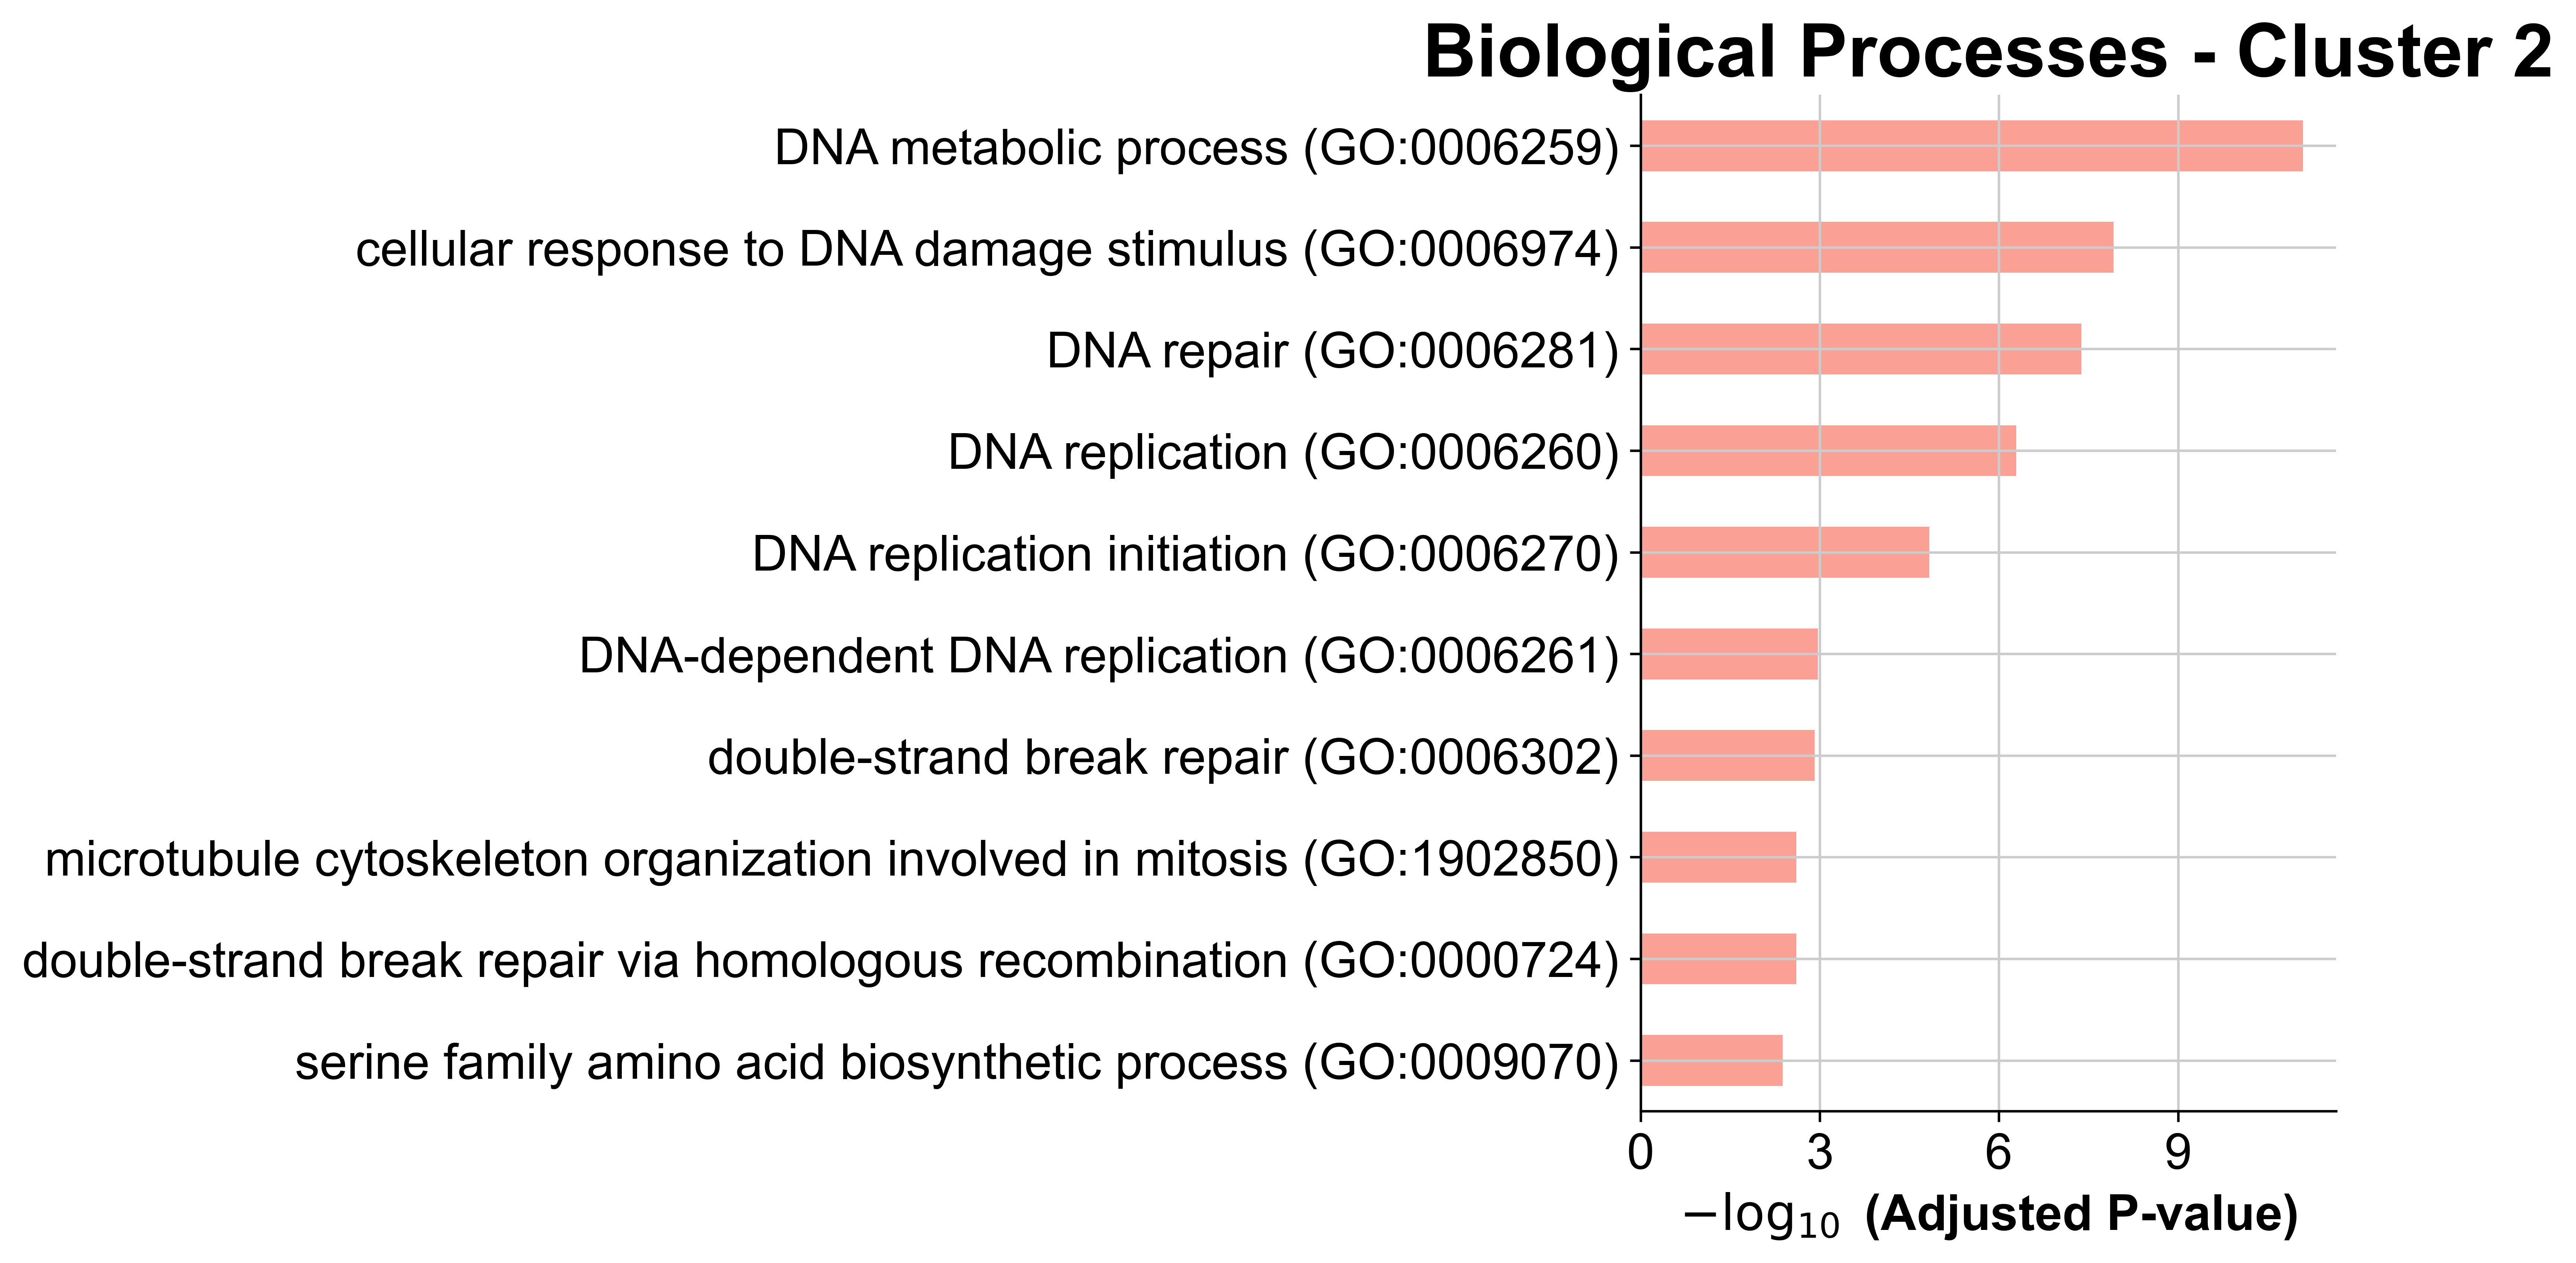

In [ ]:
# ==========================================
# VISUALIZE A SPECIFIC CLUSTER
# ==========================================
target_cluster = '2'
if target_cluster in go_results:
    gp.barplot(
        go_results[target_cluster], 
        title=f'Biological Processes - Cluster {target_cluster}', 
        top_term=10, 
        column='Adjusted P-value'
    )
    plt.show()

Check identity of mesoderm clusters 0 and 6:

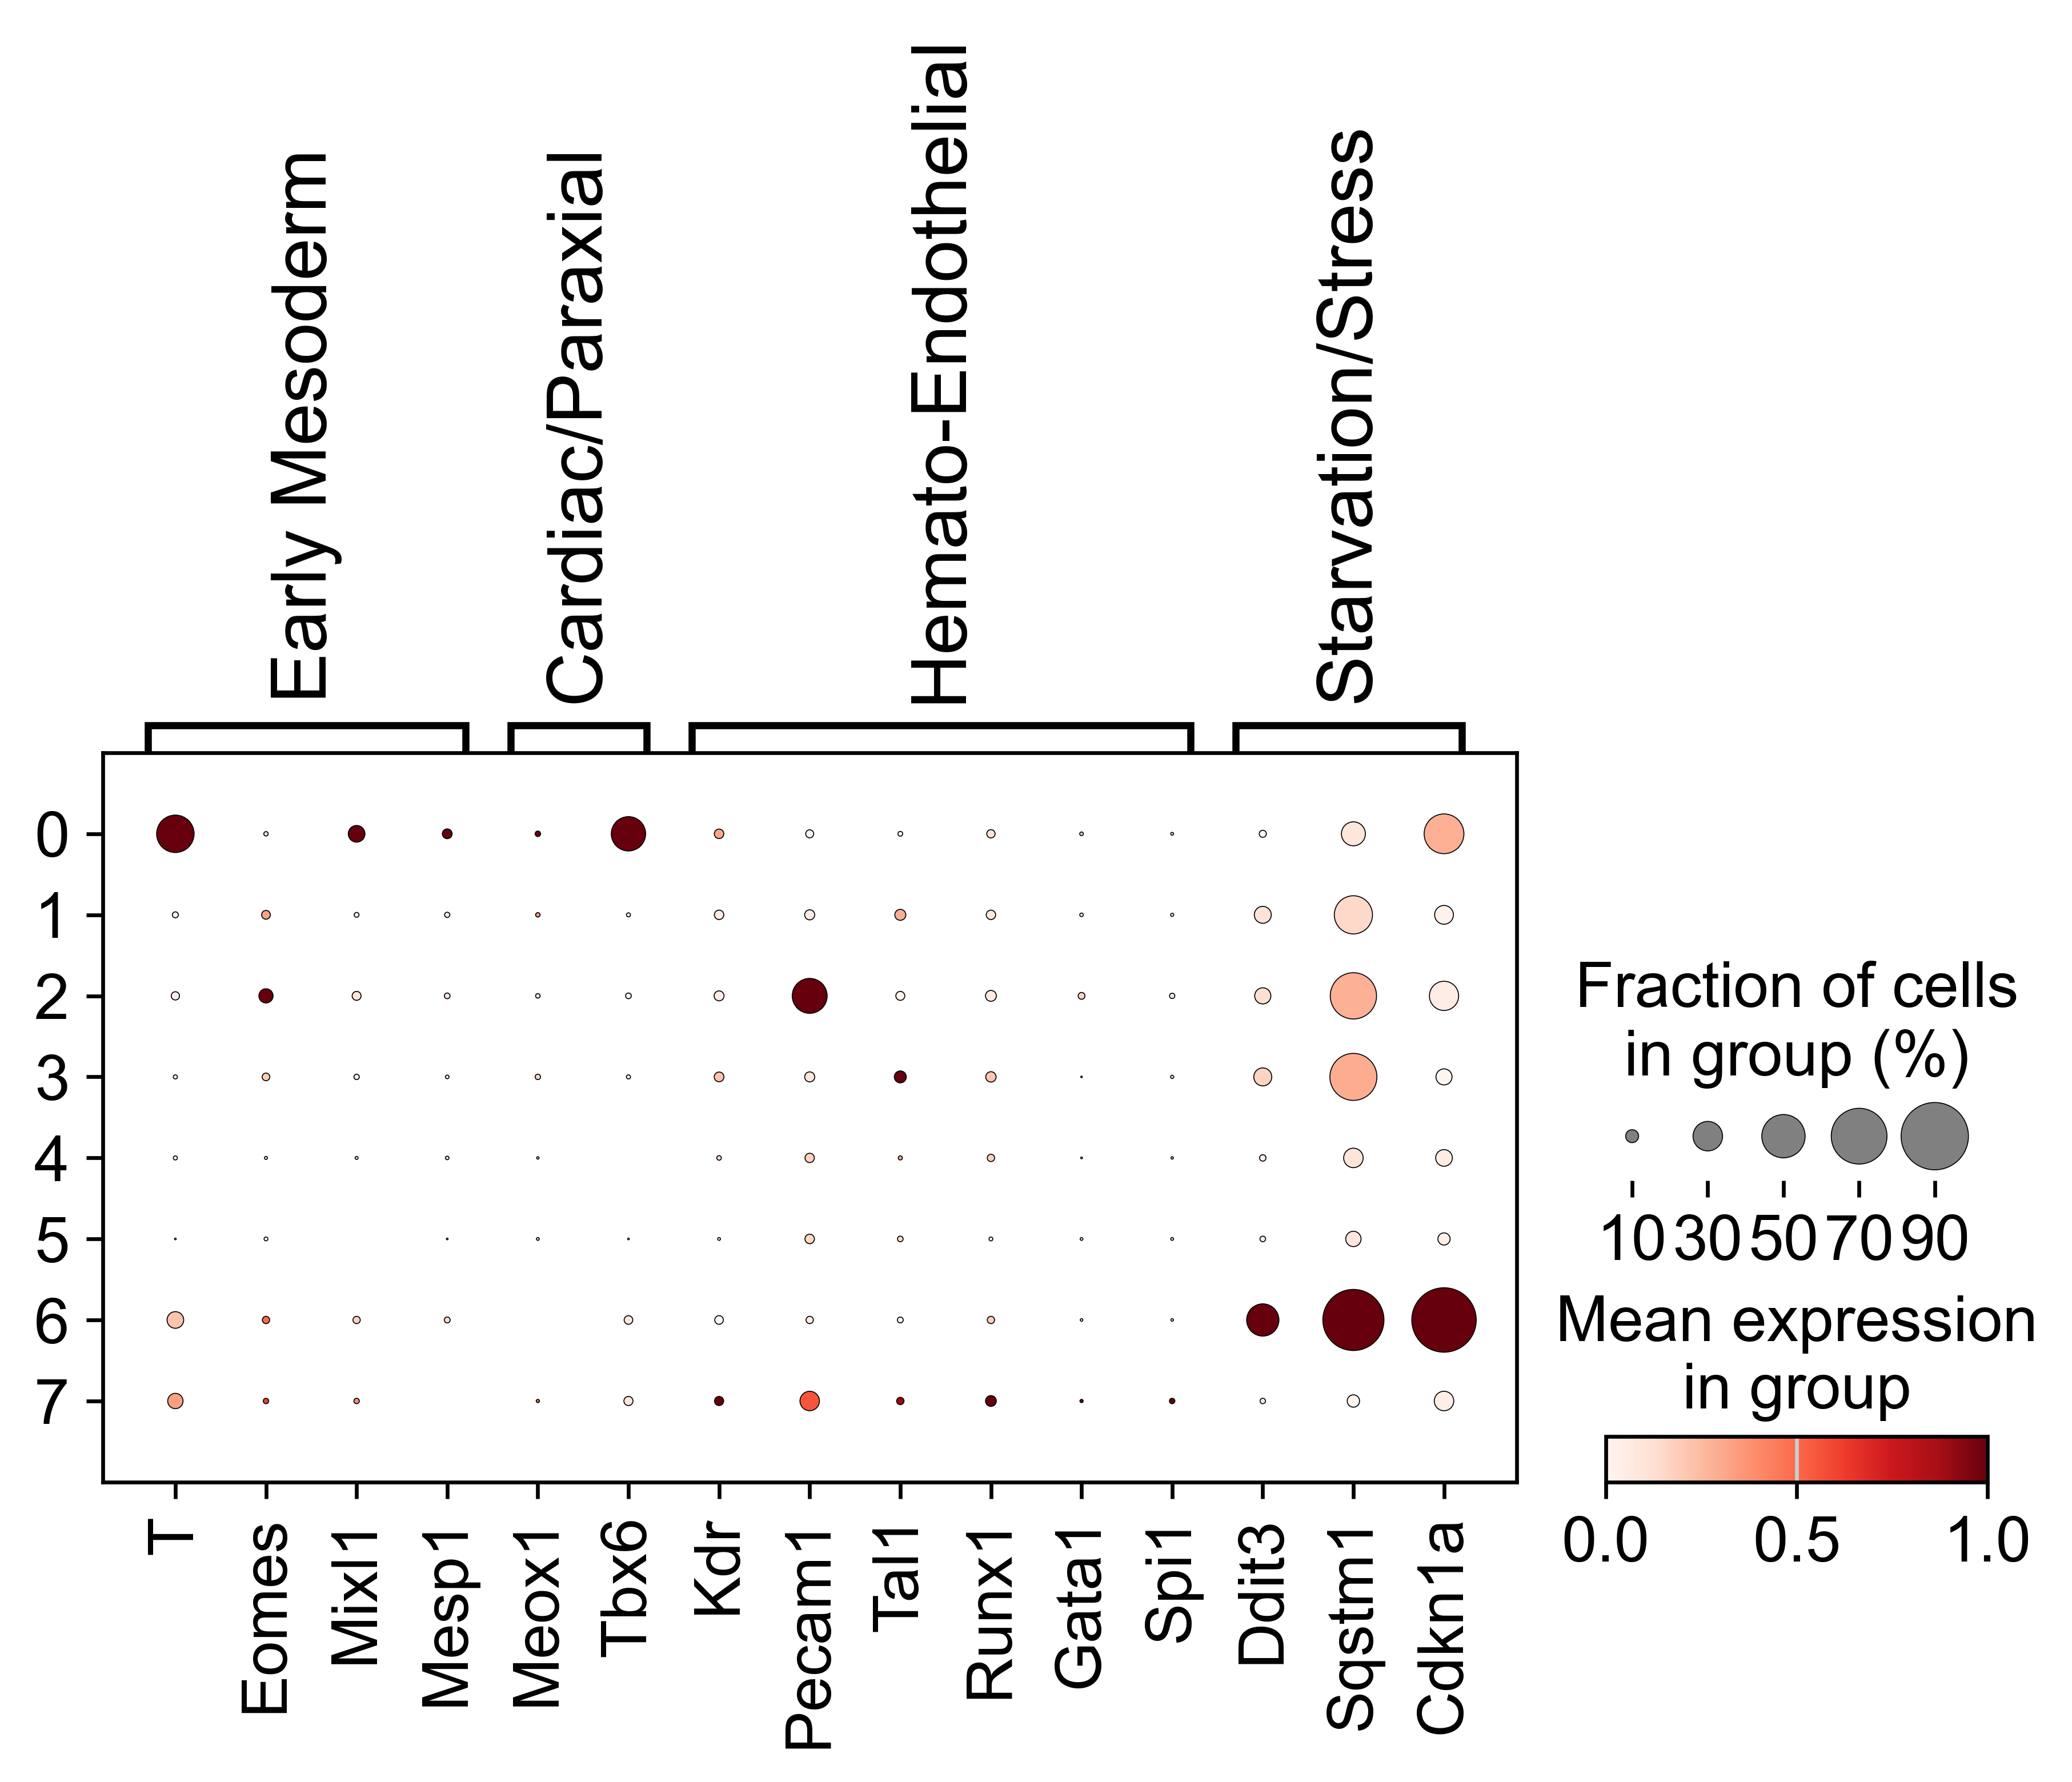

In [ ]:
# markers to distinguish mesoderm subtypes
mesoderm_subtypes = {
    # 1. Mesoderm general markers
    'Early Mesoderm': ['T', 'Eomes', 'Mixl1', 'Mesp1'],

    # 2. If cluster 0 is Cardiac or Skeletal Muscle 
    'Cardiac/Paraxial': ['Myf5', 'Meox1', 'Nkx2-5', 'Tnnt2', 'Tbx6'],

    # 3. If cluster 6 is Blood / Endothelium 
    'Hemato-Endothelial': ['Kdr', 'Pecam1', 'Tal1', 'Runx1', 'Gata1', 'Spi1'],
    
    # 4. If cluster 6 is simply starvation/stress
    'Starvation/Stress': ['Atf4', 'Ddit3', 'Sqstm1', 'Cdkn1a', 'Bax']
}

# Only genes in dataset
valid_subtypes = {k: [g for g in v if g in adata.var_names] for k, v in mesoderm_subtypes.items()}

# Plot
sc.pl.dotplot(
    adata, 
    var_names=valid_subtypes, 
    groupby='leiden', 
    use_raw=True,
    standard_scale='var', 
    cmap='Reds'
)

## Eliminate noise clusters for GRN construction

=> clusters 4 and 7

In [ ]:
print(f"Cells before filtering noisy clusters: {adata.n_obs}")

# Only conserved non-noisy clusters
noise_clusters = ['4', '7']
mask_clean = ~adata.obs['leiden'].isin(noise_clusters)
adata_grn = adata[mask_clean].copy()

# Clean categories
adata_grn.obs['leiden'] = adata_grn.obs['leiden'].cat.remove_unused_categories()

print(f"Cells after filtering: {adata_grn.n_obs}")
print(f"Remaining clusters: {list(adata_grn.obs['leiden'].unique())}")

Cells before filtering noisy clusters: 1947
Cells after filtering: 1604
Remaining clusters: ['2', '5', '3', '1', '0', '6']


In [ ]:
## UMAP without noisy clusters (but original UMAP coordinates)
mask_keep = ~adata.obs['leiden'].isin(['4', '7'])

# Plot with mask
sc.pl.umap(adata, color='leiden', 
           mask_obs=mask_keep,           # ← oculta clusters 4 y 7
           title='UMAP - clusters 4 y 7 ocultos')

## SAVE 

AnnData with the diff. expression ranks and annotated GO terms

In [ ]:
adata_grn.write("../data/data_diff_express_lncRNA.h5ad", compression="gzip")

## GO enrichment
os.makedirs("../data/clusters_GO", exist_ok=True)

for cluster, df in go_results.items():
    df.to_parquet(f"../data/clusters_GO/cluster_{cluster}.parquet", index=False)


## Later, to load all results back into a dictionary:

#go_results = {
#    os.path.basename(f).replace("cluster_", "").replace(".parquet", ""): pd.read_parquet(f)
#    for f in sorted(glob.glob("../data/clusters_GO /cluster_*.parquet"))
#}

## Pseudobulking?

Each cell is considered as an independent sample in the DE statistical text BUT in reality belong to the same biological sample (diff. protocol).

-> we need to compare between macrostates so the p-values are not artifitially inflated


In [ ]:
'''
# ==========================================
# PREPARE THE DATA 
# ==========================================

# Isolate the cluster of interest (e.g., 'Ectoderm') 
# Change '2' to your actual Ectoderm cluster
target_cluster = '2' 

# We only want to compare the specific ASO vs its Control
experiments_to_compare =['mES_ectodiff_asoNegControl', 'mES_ectodiff_asoC13']

mask = (adata.obs['leiden'] == target_cluster) & \
       (adata.obs['experiment'].isin(experiments_to_compare))

adata_sub = adata[mask].copy()

# ==========================================
# CREATE THE PSEUDOBULK PROFILES
# ==========================================

# We need the RAW INTEGER COUNTS. 
# Depending on how you stored them, extract the correct matrix:
if 'counts' in adata_sub.layers:
    counts_matrix = adata_sub.layers['counts']
elif adata_sub.raw is not None:
    # If adata.raw.X is NOT log-transformed (but earlier you said it was).
    # Please ensure you are extracting the UN-LOGGED, UN-NORMALIZED integers.
    # For safety, let's assume adata_sub.layers['counts'] contains them as defined in previous chats.
    counts_matrix = adata_sub.layers['counts']
else:
    raise ValueError("Raw counts not found. You must use the integer matrix for pseudobulk.")

# Convert to Dense DataFrame for easy grouping
if issparse(counts_matrix):
    counts_df = pd.DataFrame(counts_matrix.A, index=adata_sub.obs_names, columns=adata_sub.var_names)
else:
    counts_df = pd.DataFrame(counts_matrix, index=adata_sub.obs_names, columns=adata_sub.var_names)

# Add the macrostate variables to group by
# We group by 'experiment' AND 'plate' (or 'replicate' if you have it)
counts_df['pseudobulk_group'] = adata_sub.obs['experiment'].astype(str) + "_" + adata_sub.obs['plate'].astype(str)

# Sum all cellular counts per macrostate (The physical integration)
pseudobulk_raw = counts_df.groupby('pseudobulk_group').sum()

print("Pseudobulk matrix created:")
print(f"Shape: {pseudobulk_raw.shape} (N_Macrostates x N_Genes)")
print(pseudobulk_raw.head())

# ==========================================
# MACROSTATE NORMALIZATION
# ==========================================

# Now we treat these new aggregated vectors as standard Bulk RNA-seq samples.
# Calculate CPM (Counts Per Million)
pseudobulk_cpm = pseudobulk_raw.div(pseudobulk_raw.sum(axis=1), axis=0) * 1e6

# Log2 transform for fold change calculations (Log2(CPM + 1))
pseudobulk_log = np.log2(pseudobulk_cpm + 1)

# ==========================================
# DIFFERENTIAL EXPRESSION (BULK LEVEL)
# ==========================================

# Separate the pseudo-samples by condition
control_samples =[idx for idx in pseudobulk_log.index if 'asoNegControl' in idx]
aso_samples =[idx for idx in pseudobulk_log.index if 'asoC13' in idx]

print(f"Control Replicates: {len(control_samples)}")
print(f"ASO Replicates: {len(aso_samples)}")

if len(control_samples) < 2 or len(aso_samples) < 2:
    print("\nWARNING: You have less than 2 replicates per condition!")
    print("Classical statistics (p-values) require variance across replicates.")
    print("We will calculate the Mean Log2 Fold Change, but p-values cannot be robustly calculated.")
    
    # Just calculate the exact Fold Change between the pseudobulks
    mean_control = pseudobulk_log.loc[control_samples].mean(axis=0)
    mean_aso = pseudobulk_log.loc[aso_samples].mean(axis=0)
    logfc = mean_aso - mean_control
    
    # Create DataFrame
    results_df = pd.DataFrame({'log2FoldChange': logfc})
    
else:
    # If you have replicates, we can run a standard T-test
    from scipy.stats import ttest_ind
    
    mean_control = pseudobulk_log.loc[control_samples].mean(axis=0)
    mean_aso = pseudobulk_log.loc[aso_samples].mean(axis=0)
    logfc = mean_aso - mean_control
    
    # T-test across replicates
    t_stat, p_vals = ttest_ind(pseudobulk_log.loc[aso_samples], pseudobulk_log.loc[control_samples], axis=0)
    
    results_df = pd.DataFrame({
        'log2FoldChange': logfc,
        'pvalue': p_vals
    })
    
    # Clean up NaNs
    results_df = results_df.dropna()

print("\nTop Upregulated Genes (Robust Pseudobulk):")
print(results_df.sort_values('log2FoldChange', ascending=False).head(10))

print("\nTop Downregulated Genes (Robust Pseudobulk):")
print(results_df.sort_values('log2FoldChange', ascending=True).head(10))
'''

'\n# ==========================================\n# PREPARE THE DATA \n# ==========================================\n\n# Isolate the cluster of interest (e.g., \'Ectoderm\') \n# Change \'2\' to your actual Ectoderm cluster\ntarget_cluster = \'2\' \n\n# We only want to compare the specific ASO vs its Control\nexperiments_to_compare =[\'mES_ectodiff_asoNegControl\', \'mES_ectodiff_asoC13\']\n\nmask = (adata.obs[\'leiden\'] == target_cluster) &        (adata.obs[\'experiment\'].isin(experiments_to_compare))\n\nadata_sub = adata[mask].copy()\n\n# ==========================================\n# CREATE THE PSEUDOBULK PROFILES\n# ==========================================\n\n# We need the RAW INTEGER COUNTS. \n# Depending on how you stored them, extract the correct matrix:\nif \'counts\' in adata_sub.layers:\n    counts_matrix = adata_sub.layers[\'counts\']\nelif adata_sub.raw is not None:\n    # If adata.raw.X is NOT log-transformed (but earlier you said it was).\n    # Please ensure you are ex